In [3]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import TimeoutException
from webdriver_manager.chrome import ChromeDriverManager
import time
import csv

options = webdriver.ChromeOptions()
options.add_argument("--headless")
options.add_argument("window-size=1920,1080")

driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)
driver.get("https://www.thegioididong.com/laptop")
time.sleep(1)

# 1. Click "Xem thêm" đến khi hết sản phẩm
click_count = 0
last_count = 0
while True:
    try:
        products = driver.find_elements(By.CSS_SELECTOR, '.item.__cate_44')
        current_count = len(products)
        print(f"Tổng số sản phẩm hiện tại: {current_count}")
        if current_count == last_count:
            print(f"Không còn sản phẩm mới. Tổng số lần bấm: {click_count}")
            break

        viewmore_button = driver.find_element(By.CLASS_NAME, "see-more-btn")
        driver.execute_script("arguments[0].click();", viewmore_button)
        click_count += 1
        last_count = current_count
        print(f"Đã bấm 'Xem thêm' lần {click_count}")
        time.sleep(3)
    except:
        print(f"Lỗi hoặc không còn nút 'Xem thêm'. Tổng lần bấm: {click_count}")
        break

# 2. Mở CSV
with open('laptop_reviews.csv', mode='w', newline='', encoding='utf-8-sig') as file:
    writer = csv.writer(file)
    writer.writerow(['id_product', 'name_product', 'username', 'rating'])

    # 3. Lấy danh sách sản phẩm
    products = driver.find_elements(By.CSS_SELECTOR, '.item.__cate_44')
    links = []
    for product in products:
        try:
            a_tag = product.find_element(By.TAG_NAME, 'a')
            link = a_tag.get_attribute('href')
            name = product.find_element(By.CSS_SELECTOR, 'h3').text
            id_product = link.strip().split('/')[-1]
            links.append((id_product, name, link))
        except:
            continue

    # 4. Lặp từng sản phẩm
    for id_product, name_product, link in links:
        try:
            driver.get(link)
            print(f"\nĐang xử lý: {name_product}")
            time.sleep(2)

            # Kiểm tra có nút "Xem tất cả đánh giá"
            try:
                view_all_btn = driver.find_element(By.CSS_SELECTOR, 'a.c-btn-rate.btn-view-all')
                full_review_link = view_all_btn.get_attribute('href')
                if full_review_link.startswith('/'):
                    full_review_link = 'https://www.thegioididong.com' + full_review_link
                driver.get(full_review_link)
                time.sleep(2)
                use_pagination = True
            except:
                print("Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm")
                use_pagination = False

            # Crawl đánh giá
            if use_pagination:
                # Tìm tổng số trang (nếu có)
                try:
                    page_links = driver.find_elements(By.CSS_SELECTOR, '.pagcomment a[title^="trang "]')
                    page_numbers = [int(link.get_attribute('title').replace('trang ', '')) for link in page_links if link.text.isdigit()]
                    last_page = max(page_numbers) if page_numbers else 1
                except:
                    last_page = 1

                for page in range(1, last_page + 1):
                    try:
                        driver.execute_script(f"ratingCmtList({page})")
                        time.sleep(1.5)

                        WebDriverWait(driver, 5).until(
                            EC.presence_of_element_located((By.CSS_SELECTOR, '.comment-list'))
                        )

                        comments = driver.find_elements(By.CSS_SELECTOR, 'ul.comment-list li.par')
                        for comment in comments:
                            try:
                                username = comment.find_element(By.CSS_SELECTOR, '.cmt-top-name').text.strip()
                                stars = comment.find_elements(By.CSS_SELECTOR, '.cmt-top-star .iconcmt-starbuy')
                                rating = len(stars)
                                writer.writerow([id_product, name_product, username, rating])
                                print(f"  - {username}: {rating}")
                            except:
                                continue
                    except TimeoutException:
                        print(" Timeout khi tải đánh giá.")
                        break
            else:
                # Lấy đánh giá hiện trên trang
                try:
                    comments = driver.find_elements(By.CSS_SELECTOR, 'ul.comment-list li.par')
                    for comment in comments:
                        try:
                            username = comment.find_element(By.CSS_SELECTOR, '.cmt-top-name').text.strip()
                            stars = comment.find_elements(By.CSS_SELECTOR, '.cmt-top-star .iconcmt-starbuy')
                            rating = len(stars)
                            writer.writerow([id_product, name_product, username, rating])
                            print(f"  - {username}: {rating}")
                        except:
                            continue
                except:
                    print("Không có đánh giá nào hiển thị.")
        except Exception as e:
            print(f"Lỗi khi xử lý {name_product}: {e}")
            continue

driver.quit()
print("\nCrawl hoàn tất.")


Tổng số sản phẩm hiện tại: 20
Đã bấm 'Xem thêm' lần 1
Tổng số sản phẩm hiện tại: 40
Đã bấm 'Xem thêm' lần 2
Tổng số sản phẩm hiện tại: 60
Đã bấm 'Xem thêm' lần 3
Tổng số sản phẩm hiện tại: 80
Đã bấm 'Xem thêm' lần 4
Tổng số sản phẩm hiện tại: 100
Đã bấm 'Xem thêm' lần 5
Tổng số sản phẩm hiện tại: 120
Đã bấm 'Xem thêm' lần 6
Tổng số sản phẩm hiện tại: 140
Đã bấm 'Xem thêm' lần 7
Tổng số sản phẩm hiện tại: 160
Đã bấm 'Xem thêm' lần 8
Tổng số sản phẩm hiện tại: 180
Đã bấm 'Xem thêm' lần 9
Tổng số sản phẩm hiện tại: 200
Đã bấm 'Xem thêm' lần 10
Tổng số sản phẩm hiện tại: 220
Đã bấm 'Xem thêm' lần 11
Tổng số sản phẩm hiện tại: 240
Đã bấm 'Xem thêm' lần 12
Tổng số sản phẩm hiện tại: 260
Đã bấm 'Xem thêm' lần 13
Tổng số sản phẩm hiện tại: 280
Đã bấm 'Xem thêm' lần 14
Tổng số sản phẩm hiện tại: 300
Đã bấm 'Xem thêm' lần 15
Tổng số sản phẩm hiện tại: 320
Đã bấm 'Xem thêm' lần 16
Tổng số sản phẩm hiện tại: 339
Đã bấm 'Xem thêm' lần 17
Tổng số sản phẩm hiện tại: 358
Đã bấm 'Xem thêm' lần 18
Tổng 

In [ ]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import TimeoutException
from webdriver_manager.chrome import ChromeDriverManager
import time
import csv

options = webdriver.ChromeOptions()
options.add_argument("--headless")
options.add_argument("window-size=1920,1080")

driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)
driver.get("https://www.thegioididong.com/dtdd")
time.sleep(1)

# 1. Click "Xem thêm" đến khi hết sản phẩm
click_count = 0
last_count = 0
while True:
    try:
        products = driver.find_elements(By.CSS_SELECTOR, '.item')
        current_count = len(products)
        print(f"Tổng số sản phẩm hiện tại: {current_count}")
        if current_count == last_count:
            print(f"Không còn sản phẩm mới. Tổng số lần bấm: {click_count}")
            break

        viewmore_button = driver.find_element(By.CLASS_NAME, "see-more-btn")
        driver.execute_script("arguments[0].click();", viewmore_button)
        click_count += 1
        last_count = current_count
        print(f"Đã bấm 'Xem thêm' lần {click_count}")
        time.sleep(3)
    except:
        print(f"Lỗi hoặc không còn nút 'Xem thêm'. Tổng lần bấm: {click_count}")
        break

# 2. Mở CSV
with open('phone_reviews.csv', mode='w', newline='', encoding='utf-8-sig') as file:
    writer = csv.writer(file)
    writer.writerow(['id_product', 'name_product', 'username', 'rating'])

    # 3. Lấy danh sách sản phẩm
    products = driver.find_elements(By.CSS_SELECTOR, '.item')
    links = []
    for product in products:
        try:
            a_tag = product.find_element(By.TAG_NAME, 'a')
            link = a_tag.get_attribute('href')
            name = product.find_element(By.CSS_SELECTOR, 'h3').text
            id_product = link.strip().split('/')[-1]
            links.append((id_product, name, link))
        except:
            continue

    # 4. Lặp từng sản phẩm
    for id_product, name_product, link in links:
        try:
            driver.get(link)
            print(f"\nĐang xử lý: {name_product}")
            time.sleep(2)

            # Kiểm tra có nút "Xem tất cả đánh giá"
            try:
                view_all_btn = driver.find_element(By.CSS_SELECTOR, 'a.c-btn-rate.btn-view-all')
                full_review_link = view_all_btn.get_attribute('href')
                if full_review_link.startswith('/'):
                    full_review_link = 'https://www.thegioididong.com' + full_review_link
                driver.get(full_review_link)
                time.sleep(2)
                use_pagination = True
            except:
                print("Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm")
                use_pagination = False

            # Crawl đánh giá
            if use_pagination:
                # Tìm tổng số trang (nếu có)
                try:
                    page_links = driver.find_elements(By.CSS_SELECTOR, '.pagcomment a[title^="trang "]')
                    page_numbers = [int(link.get_attribute('title').replace('trang ', '')) for link in page_links if link.text.isdigit()]
                    last_page = max(page_numbers) if page_numbers else 1
                except:
                    last_page = 1

                for page in range(1, last_page + 1):
                    try:
                        driver.execute_script(f"ratingCmtList({page})")
                        time.sleep(1.5)

                        WebDriverWait(driver, 5).until(
                            EC.presence_of_element_located((By.CSS_SELECTOR, '.comment-list'))
                        )

                        comments = driver.find_elements(By.CSS_SELECTOR, 'ul.comment-list li.par')
                        for comment in comments:
                            try:
                                username = comment.find_element(By.CSS_SELECTOR, '.cmt-top-name').text.strip()
                                stars = comment.find_elements(By.CSS_SELECTOR, '.cmt-top-star .iconcmt-starbuy')
                                rating = len(stars)
                                writer.writerow([id_product, name_product, username, rating])
                                print(f"  - {username}: {rating}")
                            except:
                                continue
                    except TimeoutException:
                        print(" Timeout khi tải đánh giá.")
                        break
            else:
                # Lấy đánh giá hiện trên trang
                try:
                    comments = driver.find_elements(By.CSS_SELECTOR, 'ul.comment-list li.par')
                    for comment in comments:
                        try:
                            username = comment.find_element(By.CSS_SELECTOR, '.cmt-top-name').text.strip()
                            stars = comment.find_elements(By.CSS_SELECTOR, '.cmt-top-star .iconcmt-starbuy')
                            rating = len(stars)
                            writer.writerow([id_product, name_product, username, rating])
                            print(f"  - {username}: {rating}")
                        except:
                            continue
                except:
                    print("Không có đánh giá nào hiển thị.")
        except Exception as e:
            print(f"Lỗi khi xử lý {name_product}: {e}")
            continue

driver.quit()
print("\nCrawl hoàn tất.")


Tổng số sản phẩm hiện tại: 74
Đã bấm 'Xem thêm' lần 1
Tổng số sản phẩm hiện tại: 138
Đã bấm 'Xem thêm' lần 2
Tổng số sản phẩm hiện tại: 195
Đã bấm 'Xem thêm' lần 3
Tổng số sản phẩm hiện tại: 238
Đã bấm 'Xem thêm' lần 4
Tổng số sản phẩm hiện tại: 264
Đã bấm 'Xem thêm' lần 5
Tổng số sản phẩm hiện tại: 300
Đã bấm 'Xem thêm' lần 6
Tổng số sản phẩm hiện tại: 305
Đã bấm 'Xem thêm' lần 7
Tổng số sản phẩm hiện tại: 305
Không còn sản phẩm mới. Tổng số lần bấm: 7

Đang xử lý: vivo Y19s Pro 8GB/128GB
Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm

Đang xử lý: HONOR 400 5G 12GB/256GB
Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm

Đang xử lý: OPPO A5x 4GB/64GB
Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm

Đang xử lý: iPhone 16 Pro Max 256GB
  - Tuân: 4
  - Nguyễn Văn Đặng: 5
  - Huynh Duy: 5
  - Nguyễn Thị Linh: 5
  - Nguyen Van Dung: 5
  - Thuý: 1
  - Nguyễn Thị Hạnh: 5
  - Lê Oanh: 3
  - Lý Hoài Nam: 2
  - Đ

In [4]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import TimeoutException
from webdriver_manager.chrome import ChromeDriverManager
import time
import csv

options = webdriver.ChromeOptions()
options.add_argument("--headless")
options.add_argument("window-size=1920,1080")

driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)
driver.get("https://www.thegioididong.com/may-tinh-bang")
time.sleep(1)

# 1. Click "Xem thêm" đến khi hết sản phẩm
click_count = 0
last_count = 0
while True:
    try:
        products = driver.find_elements(By.CSS_SELECTOR, '.item')
        current_count = len(products)
        print(f"Tổng số sản phẩm hiện tại: {current_count}")
        if current_count == last_count:
            print(f"Không còn sản phẩm mới. Tổng số lần bấm: {click_count}")
            break

        viewmore_button = driver.find_element(By.CLASS_NAME, "see-more-btn")
        driver.execute_script("arguments[0].click();", viewmore_button)
        click_count += 1
        last_count = current_count
        print(f"Đã bấm 'Xem thêm' lần {click_count}")
        time.sleep(3)
    except:
        print(f"Lỗi hoặc không còn nút 'Xem thêm'. Tổng lần bấm: {click_count}")
        break

# 2. Mở CSV
with open('tablet_reviews.csv', mode='w', newline='', encoding='utf-8-sig') as file:
    writer = csv.writer(file)
    writer.writerow(['id_product', 'name_product', 'username', 'rating'])

    # 3. Lấy danh sách sản phẩm
    products = driver.find_elements(By.CSS_SELECTOR, '.item')
    links = []
    for product in products:
        try:
            a_tag = product.find_element(By.TAG_NAME, 'a')
            link = a_tag.get_attribute('href')
            name = product.find_element(By.CSS_SELECTOR, 'h3').text
            id_product = link.strip().split('/')[-1]
            links.append((id_product, name, link))
        except:
            continue

    # 4. Lặp từng sản phẩm
    for id_product, name_product, link in links:
        try:
            driver.get(link)
            print(f"\nĐang xử lý: {name_product}")
            time.sleep(2)

            # Kiểm tra có nút "Xem tất cả đánh giá"
            try:
                view_all_btn = driver.find_element(By.CSS_SELECTOR, 'a.c-btn-rate.btn-view-all')
                full_review_link = view_all_btn.get_attribute('href')
                if full_review_link.startswith('/'):
                    full_review_link = 'https://www.thegioididong.com' + full_review_link
                driver.get(full_review_link)
                time.sleep(2)
                use_pagination = True
            except:
                print("Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm")
                use_pagination = False

            # Crawl đánh giá
            if use_pagination:
                # Tìm tổng số trang (nếu có)
                try:
                    page_links = driver.find_elements(By.CSS_SELECTOR, '.pagcomment a[title^="trang "]')
                    page_numbers = [int(link.get_attribute('title').replace('trang ', '')) for link in page_links if link.text.isdigit()]
                    last_page = max(page_numbers) if page_numbers else 1
                except:
                    last_page = 1

                for page in range(1, last_page + 1):
                    try:
                        driver.execute_script(f"ratingCmtList({page})")
                        time.sleep(1.5)

                        WebDriverWait(driver, 5).until(
                            EC.presence_of_element_located((By.CSS_SELECTOR, '.comment-list'))
                        )

                        comments = driver.find_elements(By.CSS_SELECTOR, 'ul.comment-list li.par')
                        for comment in comments:
                            try:
                                username = comment.find_element(By.CSS_SELECTOR, '.cmt-top-name').text.strip()
                                stars = comment.find_elements(By.CSS_SELECTOR, '.cmt-top-star .iconcmt-starbuy')
                                rating = len(stars)
                                writer.writerow([id_product, name_product, username, rating])
                                print(f"  - {username}: {rating}")
                            except:
                                continue
                    except TimeoutException:
                        print(" Timeout khi tải đánh giá.")
                        break
            else:
                # Lấy đánh giá hiện trên trang
                try:
                    comments = driver.find_elements(By.CSS_SELECTOR, 'ul.comment-list li.par')
                    for comment in comments:
                        try:
                            username = comment.find_element(By.CSS_SELECTOR, '.cmt-top-name').text.strip()
                            stars = comment.find_elements(By.CSS_SELECTOR, '.cmt-top-star .iconcmt-starbuy')
                            rating = len(stars)
                            writer.writerow([id_product, name_product, username, rating])
                            print(f"  - {username}: {rating}")
                        except:
                            continue
                except:
                    print("Không có đánh giá nào hiển thị.")
        except Exception as e:
            print(f"Lỗi khi xử lý {name_product}: {e}")
            continue

driver.quit()
print("\nCrawl hoàn tất.")

Tổng số sản phẩm hiện tại: 58
Đã bấm 'Xem thêm' lần 1
Tổng số sản phẩm hiện tại: 101
Đã bấm 'Xem thêm' lần 2
Tổng số sản phẩm hiện tại: 122
Đã bấm 'Xem thêm' lần 3
Tổng số sản phẩm hiện tại: 122
Không còn sản phẩm mới. Tổng số lần bấm: 3

Đang xử lý: iPad A16 WiFi 128GB
  - Võ Văn Nghĩa: 5
  - Quan Van Quang: 4
  - Vĩnh An: 4
  - Khánh Hưng: 1

Đang xử lý: iPad Air M3 11 inch WiFi 128GB
Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm

Đang xử lý: Xiaomi Pad 7 WiFi 8GB/256GB
Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm
  - Lộc: 5

Đang xử lý: OPPO Pad 3 8GB/256GB
Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm
  - Lê Minh: 5

Đang xử lý: Samsung Galaxy Tab S10 FE WiFi 8GB/128GB
Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm
  - Lê Triệu Thế Văn: 5

Đang xử lý: Samsung Galaxy Tab S10+ WiFi 12GB/256GB
Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩ

In [5]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import TimeoutException
from webdriver_manager.chrome import ChromeDriverManager
import time
import csv

options = webdriver.ChromeOptions()
options.add_argument("--headless")
options.add_argument("window-size=1920,1080")

driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)
driver.get("https://www.thegioididong.com/dong-ho-thong-minh-xiaomi#c=7077&m=17197,17188,17196,17189,19546,17190,18728,18653,19817,36914,20482,18727&o=13&pi=0")
time.sleep(1)

# 1. Click "Xem thêm" đến khi hết sản phẩm
click_count = 0
last_count = 0
while True:
    try:
        products = driver.find_elements(By.CSS_SELECTOR, '.item')
        current_count = len(products)
        print(f"Tổng số sản phẩm hiện tại: {current_count}")
        if current_count == last_count:
            print(f"Không còn sản phẩm mới. Tổng số lần bấm: {click_count}")
            break

        viewmore_button = driver.find_element(By.CLASS_NAME, "see-more-btn")
        driver.execute_script("arguments[0].click();", viewmore_button)
        click_count += 1
        last_count = current_count
        print(f"Đã bấm 'Xem thêm' lần {click_count}")
        time.sleep(3)
    except:
        print(f"Lỗi hoặc không còn nút 'Xem thêm'. Tổng lần bấm: {click_count}")
        break

# 2. Mở CSV
with open('watch_reviews.csv', mode='w', newline='', encoding='utf-8-sig') as file:
    writer = csv.writer(file)
    writer.writerow(['id_product', 'name_product', 'username', 'rating'])

    # 3. Lấy danh sách sản phẩm
    products = driver.find_elements(By.CSS_SELECTOR, '.item')
    links = []
    for product in products:
        try:
            a_tag = product.find_element(By.TAG_NAME, 'a')
            link = a_tag.get_attribute('href')
            name = product.find_element(By.CSS_SELECTOR, 'h3').text
            id_product = link.strip().split('/')[-1]
            links.append((id_product, name, link))
        except:
            continue

    # 4. Lặp từng sản phẩm
    for id_product, name_product, link in links:
        try:
            driver.get(link)
            print(f"\nĐang xử lý: {name_product}")
            time.sleep(2)

            # Kiểm tra có nút "Xem tất cả đánh giá"
            try:
                view_all_btn = driver.find_element(By.CSS_SELECTOR, 'a.c-btn-rate.btn-view-all')
                full_review_link = view_all_btn.get_attribute('href')
                if full_review_link.startswith('/'):
                    full_review_link = 'https://www.thegioididong.com' + full_review_link
                driver.get(full_review_link)
                time.sleep(2)
                use_pagination = True
            except:
                print("Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm")
                use_pagination = False

            # Crawl đánh giá
            if use_pagination:
                # Tìm tổng số trang (nếu có)
                try:
                    page_links = driver.find_elements(By.CSS_SELECTOR, '.pagcomment a[title^="trang "]')
                    page_numbers = [int(link.get_attribute('title').replace('trang ', '')) for link in page_links if link.text.isdigit()]
                    last_page = max(page_numbers) if page_numbers else 1
                except:
                    last_page = 1

                for page in range(1, last_page + 1):
                    try:
                        driver.execute_script(f"ratingCmtList({page})")
                        time.sleep(1.5)

                        WebDriverWait(driver, 5).until(
                            EC.presence_of_element_located((By.CSS_SELECTOR, '.comment-list'))
                        )

                        comments = driver.find_elements(By.CSS_SELECTOR, 'ul.comment-list li.par')
                        for comment in comments:
                            try:
                                username = comment.find_element(By.CSS_SELECTOR, '.cmt-top-name').text.strip()
                                stars = comment.find_elements(By.CSS_SELECTOR, '.cmt-top-star .iconcmt-starbuy')
                                rating = len(stars)
                                writer.writerow([id_product, name_product, username, rating])
                                print(f"  - {username}: {rating}")
                            except:
                                continue
                    except TimeoutException:
                        print(" Timeout khi tải đánh giá.")
                        break
            else:
                # Lấy đánh giá hiện trên trang
                try:
                    comments = driver.find_elements(By.CSS_SELECTOR, 'ul.comment-list li.par')
                    for comment in comments:
                        try:
                            username = comment.find_element(By.CSS_SELECTOR, '.cmt-top-name').text.strip()
                            stars = comment.find_elements(By.CSS_SELECTOR, '.cmt-top-star .iconcmt-starbuy')
                            rating = len(stars)
                            writer.writerow([id_product, name_product, username, rating])
                            print(f"  - {username}: {rating}")
                        except:
                            continue
                except:
                    print("Không có đánh giá nào hiển thị.")
        except Exception as e:
            print(f"Lỗi khi xử lý {name_product}: {e}")
            continue

driver.quit()
print("\nCrawl hoàn tất.")

Tổng số sản phẩm hiện tại: 42
Đã bấm 'Xem thêm' lần 1
Tổng số sản phẩm hiện tại: 62
Đã bấm 'Xem thêm' lần 2
Tổng số sản phẩm hiện tại: 90
Đã bấm 'Xem thêm' lần 3
Tổng số sản phẩm hiện tại: 114
Đã bấm 'Xem thêm' lần 4
Tổng số sản phẩm hiện tại: 144
Đã bấm 'Xem thêm' lần 5
Tổng số sản phẩm hiện tại: 166
Đã bấm 'Xem thêm' lần 6
Tổng số sản phẩm hiện tại: 179
Đã bấm 'Xem thêm' lần 7
Tổng số sản phẩm hiện tại: 179
Không còn sản phẩm mới. Tổng số lần bấm: 7

Đang xử lý: Huawei Watch Fit 4 43mm dây silicone
Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm
  - Nguyễn Văn Võ: 3

Đang xử lý: Garmin Forerunner 165 43mm dây silicone
  - Nguyễn Văn Hiệp: 4
  - Phong: 5
  - Nông Tự Hùng: 5
  - HỒ THANH HÀO: 5

Đang xử lý: Kidcare Sight S1 47.5mm dây silicone
  - Hương: 3
  - Trần Văn Đông: 5
  - Thơm: 3
  - Trần Yến: 3
  - Trần Hiền: 3
  - Hải: 4
  - Vũ: 1
  - Đỗ Thi Hiền Dịu: 3
  - Phạm Thị Hồng: 1
  - Kim Phúc: 1
  - Nguyễn Thị Hồng Nhung: 3
  - NGUYEN THI HANG: 3
  - Th

In [8]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import TimeoutException
from webdriver_manager.chrome import ChromeDriverManager
import time
import csv

options = webdriver.ChromeOptions()
options.add_argument("--headless")
options.add_argument("window-size=1920,1080")

driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)
driver.get("https://www.thegioididong.com/sac-dtdd")
time.sleep(1)

# 1. Click "Xem thêm" đến khi hết sản phẩm
click_count = 0
last_count = 0
while True:
    try:
        products = driver.find_elements(By.CSS_SELECTOR, '.item')
        current_count = len(products)
        print(f"Tổng số sản phẩm hiện tại: {current_count}")
        if current_count == last_count:
            print(f"Không còn sản phẩm mới. Tổng số lần bấm: {click_count}")
            break

        viewmore_button = driver.find_element(By.CLASS_NAME, "see-more-btn")
        driver.execute_script("arguments[0].click();", viewmore_button)
        click_count += 1
        last_count = current_count
        print(f"Đã bấm 'Xem thêm' lần {click_count}")
        time.sleep(3)
    except:
        print(f"Lỗi hoặc không còn nút 'Xem thêm'. Tổng lần bấm: {click_count}")
        break

# 2. Mở CSV
with open('sac-dtdd_reviews.csv', mode='w', newline='', encoding='utf-8-sig') as file:
    writer = csv.writer(file)
    writer.writerow(['id_product', 'name_product', 'username', 'rating'])

    # 3. Lấy danh sách sản phẩm
    products = driver.find_elements(By.CSS_SELECTOR, '.item')
    links = []
    for product in products:
        try:
            a_tag = product.find_element(By.TAG_NAME, 'a')
            link = a_tag.get_attribute('href')
            name = product.find_element(By.CSS_SELECTOR, 'h3').text
            id_product = link.strip().split('/')[-1]
            links.append((id_product, name, link))
        except:
            continue

    # 4. Lặp từng sản phẩm
    for id_product, name_product, link in links:
        try:
            driver.get(link)
            print(f"\nĐang xử lý: {name_product}")
            time.sleep(2)

            # Kiểm tra có nút "Xem tất cả đánh giá"
            try:
                view_all_btn = driver.find_element(By.CSS_SELECTOR, 'a.c-btn-rate.btn-view-all')
                full_review_link = view_all_btn.get_attribute('href')
                if full_review_link.startswith('/'):
                    full_review_link = 'https://www.thegioididong.com' + full_review_link
                driver.get(full_review_link)
                time.sleep(2)
                use_pagination = True
            except:
                print("Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm")
                use_pagination = False

            # Crawl đánh giá
            if use_pagination:
                # Tìm tổng số trang (nếu có)
                try:
                    page_links = driver.find_elements(By.CSS_SELECTOR, '.pagcomment a[title^="trang "]')
                    page_numbers = [int(link.get_attribute('title').replace('trang ', '')) for link in page_links if link.text.isdigit()]
                    last_page = max(page_numbers) if page_numbers else 1
                except:
                    last_page = 1

                for page in range(1, last_page + 1):
                    try:
                        driver.execute_script(f"ratingCmtList({page})")
                        time.sleep(1.5)

                        WebDriverWait(driver, 5).until(
                            EC.presence_of_element_located((By.CSS_SELECTOR, '.comment-list'))
                        )

                        comments = driver.find_elements(By.CSS_SELECTOR, 'ul.comment-list li.par')
                        for comment in comments:
                            try:
                                username = comment.find_element(By.CSS_SELECTOR, '.cmt-top-name').text.strip()
                                stars = comment.find_elements(By.CSS_SELECTOR, '.cmt-top-star .iconcmt-starbuy')
                                rating = len(stars)
                                writer.writerow([id_product, name_product, username, rating])
                                print(f"  - {username}: {rating}")
                            except:
                                continue
                    except TimeoutException:
                        print(" Timeout khi tải đánh giá.")
                        break
            else:
                # Lấy đánh giá hiện trên trang
                try:
                    comments = driver.find_elements(By.CSS_SELECTOR, 'ul.comment-list li.par')
                    for comment in comments:
                        try:
                            username = comment.find_element(By.CSS_SELECTOR, '.cmt-top-name').text.strip()
                            stars = comment.find_elements(By.CSS_SELECTOR, '.cmt-top-star .iconcmt-starbuy')
                            rating = len(stars)
                            writer.writerow([id_product, name_product, username, rating])
                            print(f"  - {username}: {rating}")
                        except:
                            continue
                except:
                    print("Không có đánh giá nào hiển thị.")
        except Exception as e:
            print(f"Lỗi khi xử lý {name_product}: {e}")
            continue

driver.quit()
print("\nCrawl hoàn tất.")

Tổng số sản phẩm hiện tại: 28
Đã bấm 'Xem thêm' lần 1
Tổng số sản phẩm hiện tại: 48
Đã bấm 'Xem thêm' lần 2
Tổng số sản phẩm hiện tại: 68
Đã bấm 'Xem thêm' lần 3
Tổng số sản phẩm hiện tại: 88
Đã bấm 'Xem thêm' lần 4
Tổng số sản phẩm hiện tại: 89
Đã bấm 'Xem thêm' lần 5
Tổng số sản phẩm hiện tại: 89
Không còn sản phẩm mới. Tổng số lần bấm: 5

Đang xử lý: Xmobile 45W MH803 kèm Cáp Lightning và Type C
Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm
  - Thuy: 3

Đang xử lý: Ugreen 20W PB206
  - Gia Long Vũ: 5
  - Sang: 5
  - Lê Văn Hiền: 5
  - Trần Ngọc Nhã Uyên: 4

Đang xử lý: Xmobile 55W JP326
Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm
  - Bùi Văn Hậu: 3

Đang xử lý: Xmobile 22.5W NeoMice GN-82 kèm Cáp Lightning và Type C
Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm

Đang xử lý: Xiaomi 33W PB1033MI kèm Cáp Type C
Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm
  - Quách

In [9]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import TimeoutException
from webdriver_manager.chrome import ChromeDriverManager
import time
import csv

options = webdriver.ChromeOptions()
options.add_argument("--headless")
options.add_argument("window-size=1920,1080")

driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)
driver.get("https://www.thegioididong.com/sac-cap")
time.sleep(1)

# 1. Click "Xem thêm" đến khi hết sản phẩm
click_count = 0
last_count = 0
while True:
    try:
        products = driver.find_elements(By.CSS_SELECTOR, '.item')
        current_count = len(products)
        print(f"Tổng số sản phẩm hiện tại: {current_count}")
        if current_count == last_count:
            print(f"Không còn sản phẩm mới. Tổng số lần bấm: {click_count}")
            break

        viewmore_button = driver.find_element(By.CLASS_NAME, "see-more-btn")
        driver.execute_script("arguments[0].click();", viewmore_button)
        click_count += 1
        last_count = current_count
        print(f"Đã bấm 'Xem thêm' lần {click_count}")
        time.sleep(3)
    except:
        print(f"Lỗi hoặc không còn nút 'Xem thêm'. Tổng lần bấm: {click_count}")
        break

# 2. Mở CSV
with open('sac-cap_reviews.csv', mode='w', newline='', encoding='utf-8-sig') as file:
    writer = csv.writer(file)
    writer.writerow(['id_product', 'name_product', 'username', 'rating'])

    # 3. Lấy danh sách sản phẩm
    products = driver.find_elements(By.CSS_SELECTOR, '.item')
    links = []
    for product in products:
        try:
            a_tag = product.find_element(By.TAG_NAME, 'a')
            link = a_tag.get_attribute('href')
            name = product.find_element(By.CSS_SELECTOR, 'h3').text
            id_product = link.strip().split('/')[-1]
            links.append((id_product, name, link))
        except:
            continue

    # 4. Lặp từng sản phẩm
    for id_product, name_product, link in links:
        try:
            driver.get(link)
            print(f"\nĐang xử lý: {name_product}")
            time.sleep(2)

            # Kiểm tra có nút "Xem tất cả đánh giá"
            try:
                view_all_btn = driver.find_element(By.CSS_SELECTOR, 'a.c-btn-rate.btn-view-all')
                full_review_link = view_all_btn.get_attribute('href')
                if full_review_link.startswith('/'):
                    full_review_link = 'https://www.thegioididong.com' + full_review_link
                driver.get(full_review_link)
                time.sleep(2)
                use_pagination = True
            except:
                print("Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm")
                use_pagination = False

            # Crawl đánh giá
            if use_pagination:
                # Tìm tổng số trang (nếu có)
                try:
                    page_links = driver.find_elements(By.CSS_SELECTOR, '.pagcomment a[title^="trang "]')
                    page_numbers = [int(link.get_attribute('title').replace('trang ', '')) for link in page_links if link.text.isdigit()]
                    last_page = max(page_numbers) if page_numbers else 1
                except:
                    last_page = 1

                for page in range(1, last_page + 1):
                    try:
                        driver.execute_script(f"ratingCmtList({page})")
                        time.sleep(1.5)

                        WebDriverWait(driver, 5).until(
                            EC.presence_of_element_located((By.CSS_SELECTOR, '.comment-list'))
                        )

                        comments = driver.find_elements(By.CSS_SELECTOR, 'ul.comment-list li.par')
                        for comment in comments:
                            try:
                                username = comment.find_element(By.CSS_SELECTOR, '.cmt-top-name').text.strip()
                                stars = comment.find_elements(By.CSS_SELECTOR, '.cmt-top-star .iconcmt-starbuy')
                                rating = len(stars)
                                writer.writerow([id_product, name_product, username, rating])
                                print(f"  - {username}: {rating}")
                            except:
                                continue
                    except TimeoutException:
                        print(" Timeout khi tải đánh giá.")
                        break
            else:
                # Lấy đánh giá hiện trên trang
                try:
                    comments = driver.find_elements(By.CSS_SELECTOR, 'ul.comment-list li.par')
                    for comment in comments:
                        try:
                            username = comment.find_element(By.CSS_SELECTOR, '.cmt-top-name').text.strip()
                            stars = comment.find_elements(By.CSS_SELECTOR, '.cmt-top-star .iconcmt-starbuy')
                            rating = len(stars)
                            writer.writerow([id_product, name_product, username, rating])
                            print(f"  - {username}: {rating}")
                        except:
                            continue
                except:
                    print("Không có đánh giá nào hiển thị.")
        except Exception as e:
            print(f"Lỗi khi xử lý {name_product}: {e}")
            continue

driver.quit()
print("\nCrawl hoàn tất.")

Tổng số sản phẩm hiện tại: 26
Đã bấm 'Xem thêm' lần 1
Tổng số sản phẩm hiện tại: 46
Đã bấm 'Xem thêm' lần 2
Tổng số sản phẩm hiện tại: 66
Đã bấm 'Xem thêm' lần 3
Tổng số sản phẩm hiện tại: 86
Đã bấm 'Xem thêm' lần 4
Tổng số sản phẩm hiện tại: 106
Đã bấm 'Xem thêm' lần 5
Tổng số sản phẩm hiện tại: 126
Đã bấm 'Xem thêm' lần 6
Tổng số sản phẩm hiện tại: 146
Đã bấm 'Xem thêm' lần 7
Tổng số sản phẩm hiện tại: 166
Đã bấm 'Xem thêm' lần 8
Tổng số sản phẩm hiện tại: 186
Đã bấm 'Xem thêm' lần 9
Tổng số sản phẩm hiện tại: 206
Đã bấm 'Xem thêm' lần 10
Tổng số sản phẩm hiện tại: 226
Đã bấm 'Xem thêm' lần 11
Tổng số sản phẩm hiện tại: 246
Đã bấm 'Xem thêm' lần 12
Tổng số sản phẩm hiện tại: 266
Đã bấm 'Xem thêm' lần 13
Tổng số sản phẩm hiện tại: 281
Đã bấm 'Xem thêm' lần 14
Tổng số sản phẩm hiện tại: 281
Không còn sản phẩm mới. Tổng số lần bấm: 14

Đang xử lý: Cáp Type C - Type C 2m Xmobile DR-T11
Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm
  - Hoàng Lập: 3

Đang xử l

In [11]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import TimeoutException
from webdriver_manager.chrome import ChromeDriverManager
import time
import csv

options = webdriver.ChromeOptions()
options.add_argument("--headless")
options.add_argument("window-size=1920,1080")

driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)
driver.get("https://www.thegioididong.com/op-lung-flipcover")
time.sleep(1)

# 1. Click "Xem thêm" đến khi hết sản phẩm
click_count = 0
last_count = 0
while True:
    try:
        products = driver.find_elements(By.CSS_SELECTOR, '.item')
        current_count = len(products)
        print(f"Tổng số sản phẩm hiện tại: {current_count}")
        if current_count == last_count:
            print(f"Không còn sản phẩm mới. Tổng số lần bấm: {click_count}")
            break

        viewmore_button = driver.find_element(By.CLASS_NAME, "see-more-btn")
        driver.execute_script("arguments[0].click();", viewmore_button)
        click_count += 1
        last_count = current_count
        print(f"Đã bấm 'Xem thêm' lần {click_count}")
        time.sleep(3)
    except:
        print(f"Lỗi hoặc không còn nút 'Xem thêm'. Tổng lần bấm: {click_count}")
        break

# 2. Mở CSV
with open('op-lung-flipcover_reviews.csv', mode='w', newline='', encoding='utf-8-sig') as file:
    writer = csv.writer(file)
    writer.writerow(['id_product', 'name_product', 'username', 'rating'])

    # 3. Lấy danh sách sản phẩm
    products = driver.find_elements(By.CSS_SELECTOR, '.item')
    links = []
    for product in products:
        try:
            a_tag = product.find_element(By.TAG_NAME, 'a')
            link = a_tag.get_attribute('href')
            name = product.find_element(By.CSS_SELECTOR, 'h3').text
            id_product = link.strip().split('/')[-1]
            links.append((id_product, name, link))
        except:
            continue

    # 4. Lặp từng sản phẩm
    for id_product, name_product, link in links:
        try:
            driver.get(link)
            print(f"\nĐang xử lý: {name_product}")
            time.sleep(2)

            # Kiểm tra có nút "Xem tất cả đánh giá"
            try:
                view_all_btn = driver.find_element(By.CSS_SELECTOR, 'a.c-btn-rate.btn-view-all')
                full_review_link = view_all_btn.get_attribute('href')
                if full_review_link.startswith('/'):
                    full_review_link = 'https://www.thegioididong.com' + full_review_link
                driver.get(full_review_link)
                time.sleep(2)
                use_pagination = True
            except:
                print("Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm")
                use_pagination = False

            # Crawl đánh giá
            if use_pagination:
                # Tìm tổng số trang (nếu có)
                try:
                    page_links = driver.find_elements(By.CSS_SELECTOR, '.pagcomment a[title^="trang "]')
                    page_numbers = [int(link.get_attribute('title').replace('trang ', '')) for link in page_links if link.text.isdigit()]
                    last_page = max(page_numbers) if page_numbers else 1
                except:
                    last_page = 1

                for page in range(1, last_page + 1):
                    try:
                        driver.execute_script(f"ratingCmtList({page})")
                        time.sleep(1.5)

                        WebDriverWait(driver, 5).until(
                            EC.presence_of_element_located((By.CSS_SELECTOR, '.comment-list'))
                        )

                        comments = driver.find_elements(By.CSS_SELECTOR, 'ul.comment-list li.par')
                        for comment in comments:
                            try:
                                username = comment.find_element(By.CSS_SELECTOR, '.cmt-top-name').text.strip()
                                stars = comment.find_elements(By.CSS_SELECTOR, '.cmt-top-star .iconcmt-starbuy')
                                rating = len(stars)
                                writer.writerow([id_product, name_product, username, rating])
                                print(f"  - {username}: {rating}")
                            except:
                                continue
                    except TimeoutException:
                        print(" Timeout khi tải đánh giá.")
                        break
            else:
                # Lấy đánh giá hiện trên trang
                try:
                    comments = driver.find_elements(By.CSS_SELECTOR, 'ul.comment-list li.par')
                    for comment in comments:
                        try:
                            username = comment.find_element(By.CSS_SELECTOR, '.cmt-top-name').text.strip()
                            stars = comment.find_elements(By.CSS_SELECTOR, '.cmt-top-star .iconcmt-starbuy')
                            rating = len(stars)
                            writer.writerow([id_product, name_product, username, rating])
                            print(f"  - {username}: {rating}")
                        except:
                            continue
                except:
                    print("Không có đánh giá nào hiển thị.")
        except Exception as e:
            print(f"Lỗi khi xử lý {name_product}: {e}")
            continue

driver.quit()
print("\nCrawl hoàn tất.")

Tổng số sản phẩm hiện tại: 24
Đã bấm 'Xem thêm' lần 1
Tổng số sản phẩm hiện tại: 44
Đã bấm 'Xem thêm' lần 2
Tổng số sản phẩm hiện tại: 64
Đã bấm 'Xem thêm' lần 3
Tổng số sản phẩm hiện tại: 84
Đã bấm 'Xem thêm' lần 4
Tổng số sản phẩm hiện tại: 104
Đã bấm 'Xem thêm' lần 5
Tổng số sản phẩm hiện tại: 124
Đã bấm 'Xem thêm' lần 6
Tổng số sản phẩm hiện tại: 144
Đã bấm 'Xem thêm' lần 7
Tổng số sản phẩm hiện tại: 164
Đã bấm 'Xem thêm' lần 8
Tổng số sản phẩm hiện tại: 184
Đã bấm 'Xem thêm' lần 9
Tổng số sản phẩm hiện tại: 204
Đã bấm 'Xem thêm' lần 10
Tổng số sản phẩm hiện tại: 224
Đã bấm 'Xem thêm' lần 11
Tổng số sản phẩm hiện tại: 244
Đã bấm 'Xem thêm' lần 12
Tổng số sản phẩm hiện tại: 264
Đã bấm 'Xem thêm' lần 13
Tổng số sản phẩm hiện tại: 284
Đã bấm 'Xem thêm' lần 14
Tổng số sản phẩm hiện tại: 304
Đã bấm 'Xem thêm' lần 15
Tổng số sản phẩm hiện tại: 324
Đã bấm 'Xem thêm' lần 16
Tổng số sản phẩm hiện tại: 344
Đã bấm 'Xem thêm' lần 17
Tổng số sản phẩm hiện tại: 364
Đã bấm 'Xem thêm' lần 18
Tổng 

In [12]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import TimeoutException
from webdriver_manager.chrome import ChromeDriverManager
import time
import csv

options = webdriver.ChromeOptions()
options.add_argument("--headless")
options.add_argument("window-size=1920,1080")

driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)
driver.get("https://www.thegioididong.com/op-lung-may-tinh-bang")
time.sleep(1)

# 1. Click "Xem thêm" đến khi hết sản phẩm
click_count = 0
last_count = 0
while True:
    try:
        products = driver.find_elements(By.CSS_SELECTOR, '.item')
        current_count = len(products)
        print(f"Tổng số sản phẩm hiện tại: {current_count}")
        if current_count == last_count:
            print(f"Không còn sản phẩm mới. Tổng số lần bấm: {click_count}")
            break

        viewmore_button = driver.find_element(By.CLASS_NAME, "see-more-btn")
        driver.execute_script("arguments[0].click();", viewmore_button)
        click_count += 1
        last_count = current_count
        print(f"Đã bấm 'Xem thêm' lần {click_count}")
        time.sleep(3)
    except:
        print(f"Lỗi hoặc không còn nút 'Xem thêm'. Tổng lần bấm: {click_count}")
        break

# 2. Mở CSV
with open('op-lung-may-tinh-bang_reviews.csv', mode='w', newline='', encoding='utf-8-sig') as file:
    writer = csv.writer(file)
    writer.writerow(['id_product', 'name_product', 'username', 'rating'])

    # 3. Lấy danh sách sản phẩm
    products = driver.find_elements(By.CSS_SELECTOR, '.item')
    links = []
    for product in products:
        try:
            a_tag = product.find_element(By.TAG_NAME, 'a')
            link = a_tag.get_attribute('href')
            name = product.find_element(By.CSS_SELECTOR, 'h3').text
            id_product = link.strip().split('/')[-1]
            links.append((id_product, name, link))
        except:
            continue

    # 4. Lặp từng sản phẩm
    for id_product, name_product, link in links:
        try:
            driver.get(link)
            print(f"\nĐang xử lý: {name_product}")
            time.sleep(2)

            # Kiểm tra có nút "Xem tất cả đánh giá"
            try:
                view_all_btn = driver.find_element(By.CSS_SELECTOR, 'a.c-btn-rate.btn-view-all')
                full_review_link = view_all_btn.get_attribute('href')
                if full_review_link.startswith('/'):
                    full_review_link = 'https://www.thegioididong.com' + full_review_link
                driver.get(full_review_link)
                time.sleep(2)
                use_pagination = True
            except:
                print("Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm")
                use_pagination = False

            # Crawl đánh giá
            if use_pagination:
                # Tìm tổng số trang (nếu có)
                try:
                    page_links = driver.find_elements(By.CSS_SELECTOR, '.pagcomment a[title^="trang "]')
                    page_numbers = [int(link.get_attribute('title').replace('trang ', '')) for link in page_links if link.text.isdigit()]
                    last_page = max(page_numbers) if page_numbers else 1
                except:
                    last_page = 1

                for page in range(1, last_page + 1):
                    try:
                        driver.execute_script(f"ratingCmtList({page})")
                        time.sleep(1.5)

                        WebDriverWait(driver, 5).until(
                            EC.presence_of_element_located((By.CSS_SELECTOR, '.comment-list'))
                        )

                        comments = driver.find_elements(By.CSS_SELECTOR, 'ul.comment-list li.par')
                        for comment in comments:
                            try:
                                username = comment.find_element(By.CSS_SELECTOR, '.cmt-top-name').text.strip()
                                stars = comment.find_elements(By.CSS_SELECTOR, '.cmt-top-star .iconcmt-starbuy')
                                rating = len(stars)
                                writer.writerow([id_product, name_product, username, rating])
                                print(f"  - {username}: {rating}")
                            except:
                                continue
                    except TimeoutException:
                        print(" Timeout khi tải đánh giá.")
                        break
            else:
                # Lấy đánh giá hiện trên trang
                try:
                    comments = driver.find_elements(By.CSS_SELECTOR, 'ul.comment-list li.par')
                    for comment in comments:
                        try:
                            username = comment.find_element(By.CSS_SELECTOR, '.cmt-top-name').text.strip()
                            stars = comment.find_elements(By.CSS_SELECTOR, '.cmt-top-star .iconcmt-starbuy')
                            rating = len(stars)
                            writer.writerow([id_product, name_product, username, rating])
                            print(f"  - {username}: {rating}")
                        except:
                            continue
                except:
                    print("Không có đánh giá nào hiển thị.")
        except Exception as e:
            print(f"Lỗi khi xử lý {name_product}: {e}")
            continue

driver.quit()
print("\nCrawl hoàn tất.")

Tổng số sản phẩm hiện tại: 24
Đã bấm 'Xem thêm' lần 1
Tổng số sản phẩm hiện tại: 44
Đã bấm 'Xem thêm' lần 2
Tổng số sản phẩm hiện tại: 61
Đã bấm 'Xem thêm' lần 3
Tổng số sản phẩm hiện tại: 61
Không còn sản phẩm mới. Tổng số lần bấm: 3

Đang xử lý: Bao da Galaxy Tab A9+ Samsung
Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm
  - Lê Lan Anh: 5
  - Trần Hoài Linh: 5

Đang xử lý: Bao da Galaxy Tab S9/ Tab S9 FE/ Tab S10 FE Samsung kèm bàn phím AI
Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm

Đang xử lý: Bao da nắp gập A16/ iPad 10 TPU PU ESR Rebound Magnetic
Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm

Đang xử lý: Bao da Galaxy Tab A9 Samsung
Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm
  - Thanh: 5
  - Anh Vân: 5

Đang xử lý: Bao da Galaxy Tab S9/ Tab S9 FE/ Tab S10 FE Samsung Thông minh
Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm
  - Ng

In [13]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import TimeoutException
from webdriver_manager.chrome import ChromeDriverManager
import time
import csv

options = webdriver.ChromeOptions()
options.add_argument("--headless")
options.add_argument("window-size=1920,1080")

driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)
driver.get("https://www.thegioididong.com/mieng-dan-man-hinh")
time.sleep(1)

# 1. Click "Xem thêm" đến khi hết sản phẩm
click_count = 0
last_count = 0
while True:
    try:
        products = driver.find_elements(By.CSS_SELECTOR, '.item')
        current_count = len(products)
        print(f"Tổng số sản phẩm hiện tại: {current_count}")
        if current_count == last_count:
            print(f"Không còn sản phẩm mới. Tổng số lần bấm: {click_count}")
            break

        viewmore_button = driver.find_element(By.CLASS_NAME, "see-more-btn")
        driver.execute_script("arguments[0].click();", viewmore_button)
        click_count += 1
        last_count = current_count
        print(f"Đã bấm 'Xem thêm' lần {click_count}")
        time.sleep(3)
    except:
        print(f"Lỗi hoặc không còn nút 'Xem thêm'. Tổng lần bấm: {click_count}")
        break

# 2. Mở CSV
with open('mieng-dan-man-hinh_reviews.csv', mode='w', newline='', encoding='utf-8-sig') as file:
    writer = csv.writer(file)
    writer.writerow(['id_product', 'name_product', 'username', 'rating'])

    # 3. Lấy danh sách sản phẩm
    products = driver.find_elements(By.CSS_SELECTOR, '.item')
    links = []
    for product in products:
        try:
            a_tag = product.find_element(By.TAG_NAME, 'a')
            link = a_tag.get_attribute('href')
            name = product.find_element(By.CSS_SELECTOR, 'h3').text
            id_product = link.strip().split('/')[-1]
            links.append((id_product, name, link))
        except:
            continue

    # 4. Lặp từng sản phẩm
    for id_product, name_product, link in links:
        try:
            driver.get(link)
            print(f"\nĐang xử lý: {name_product}")
            time.sleep(2)

            # Kiểm tra có nút "Xem tất cả đánh giá"
            try:
                view_all_btn = driver.find_element(By.CSS_SELECTOR, 'a.c-btn-rate.btn-view-all')
                full_review_link = view_all_btn.get_attribute('href')
                if full_review_link.startswith('/'):
                    full_review_link = 'https://www.thegioididong.com' + full_review_link
                driver.get(full_review_link)
                time.sleep(2)
                use_pagination = True
            except:
                print("Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm")
                use_pagination = False

            # Crawl đánh giá
            if use_pagination:
                # Tìm tổng số trang (nếu có)
                try:
                    page_links = driver.find_elements(By.CSS_SELECTOR, '.pagcomment a[title^="trang "]')
                    page_numbers = [int(link.get_attribute('title').replace('trang ', '')) for link in page_links if link.text.isdigit()]
                    last_page = max(page_numbers) if page_numbers else 1
                except:
                    last_page = 1

                for page in range(1, last_page + 1):
                    try:
                        driver.execute_script(f"ratingCmtList({page})")
                        time.sleep(1.5)

                        WebDriverWait(driver, 5).until(
                            EC.presence_of_element_located((By.CSS_SELECTOR, '.comment-list'))
                        )

                        comments = driver.find_elements(By.CSS_SELECTOR, 'ul.comment-list li.par')
                        for comment in comments:
                            try:
                                username = comment.find_element(By.CSS_SELECTOR, '.cmt-top-name').text.strip()
                                stars = comment.find_elements(By.CSS_SELECTOR, '.cmt-top-star .iconcmt-starbuy')
                                rating = len(stars)
                                writer.writerow([id_product, name_product, username, rating])
                                print(f"  - {username}: {rating}")
                            except:
                                continue
                    except TimeoutException:
                        print(" Timeout khi tải đánh giá.")
                        break
            else:
                # Lấy đánh giá hiện trên trang
                try:
                    comments = driver.find_elements(By.CSS_SELECTOR, 'ul.comment-list li.par')
                    for comment in comments:
                        try:
                            username = comment.find_element(By.CSS_SELECTOR, '.cmt-top-name').text.strip()
                            stars = comment.find_elements(By.CSS_SELECTOR, '.cmt-top-star .iconcmt-starbuy')
                            rating = len(stars)
                            writer.writerow([id_product, name_product, username, rating])
                            print(f"  - {username}: {rating}")
                        except:
                            continue
                except:
                    print("Không có đánh giá nào hiển thị.")
        except Exception as e:
            print(f"Lỗi khi xử lý {name_product}: {e}")
            continue

driver.quit()
print("\nCrawl hoàn tất.")

Tổng số sản phẩm hiện tại: 21
Đã bấm 'Xem thêm' lần 1
Tổng số sản phẩm hiện tại: 41
Đã bấm 'Xem thêm' lần 2
Tổng số sản phẩm hiện tại: 61
Đã bấm 'Xem thêm' lần 3
Tổng số sản phẩm hiện tại: 81
Đã bấm 'Xem thêm' lần 4
Tổng số sản phẩm hiện tại: 101
Đã bấm 'Xem thêm' lần 5
Tổng số sản phẩm hiện tại: 121
Đã bấm 'Xem thêm' lần 6
Tổng số sản phẩm hiện tại: 141
Đã bấm 'Xem thêm' lần 7
Tổng số sản phẩm hiện tại: 161
Đã bấm 'Xem thêm' lần 8
Tổng số sản phẩm hiện tại: 164
Đã bấm 'Xem thêm' lần 9
Tổng số sản phẩm hiện tại: 164
Không còn sản phẩm mới. Tổng số lần bấm: 9

Đang xử lý: Miếng dán kính cường lực iPhone 16 Pro Max Premium Jincase
Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm

Đang xử lý: Miếng dán kính cường lực iPhone 16 Premium Jincase
Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm

Đang xử lý: Miếng dán kính cường lực iPhone 16 Pro Premium Jincase
Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm

Đa

In [14]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import TimeoutException
from webdriver_manager.chrome import ChromeDriverManager
import time
import csv

options = webdriver.ChromeOptions()
options.add_argument("--headless")
options.add_argument("window-size=1920,1080")

driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)
driver.get("https://www.thegioididong.com/mieng-dan-camera")
time.sleep(1)

# 1. Click "Xem thêm" đến khi hết sản phẩm
click_count = 0
last_count = 0
while True:
    try:
        products = driver.find_elements(By.CSS_SELECTOR, '.item')
        current_count = len(products)
        print(f"Tổng số sản phẩm hiện tại: {current_count}")
        if current_count == last_count:
            print(f"Không còn sản phẩm mới. Tổng số lần bấm: {click_count}")
            break

        viewmore_button = driver.find_element(By.CLASS_NAME, "see-more-btn")
        driver.execute_script("arguments[0].click();", viewmore_button)
        click_count += 1
        last_count = current_count
        print(f"Đã bấm 'Xem thêm' lần {click_count}")
        time.sleep(3)
    except:
        print(f"Lỗi hoặc không còn nút 'Xem thêm'. Tổng lần bấm: {click_count}")
        break

# 2. Mở CSV
with open('mieng-dan-camera_reviews.csv', mode='w', newline='', encoding='utf-8-sig') as file:
    writer = csv.writer(file)
    writer.writerow(['id_product', 'name_product', 'username', 'rating'])

    # 3. Lấy danh sách sản phẩm
    products = driver.find_elements(By.CSS_SELECTOR, '.item')
    links = []
    for product in products:
        try:
            a_tag = product.find_element(By.TAG_NAME, 'a')
            link = a_tag.get_attribute('href')
            name = product.find_element(By.CSS_SELECTOR, 'h3').text
            id_product = link.strip().split('/')[-1]
            links.append((id_product, name, link))
        except:
            continue

    # 4. Lặp từng sản phẩm
    for id_product, name_product, link in links:
        try:
            driver.get(link)
            print(f"\nĐang xử lý: {name_product}")
            time.sleep(2)

            # Kiểm tra có nút "Xem tất cả đánh giá"
            try:
                view_all_btn = driver.find_element(By.CSS_SELECTOR, 'a.c-btn-rate.btn-view-all')
                full_review_link = view_all_btn.get_attribute('href')
                if full_review_link.startswith('/'):
                    full_review_link = 'https://www.thegioididong.com' + full_review_link
                driver.get(full_review_link)
                time.sleep(2)
                use_pagination = True
            except:
                print("Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm")
                use_pagination = False

            # Crawl đánh giá
            if use_pagination:
                # Tìm tổng số trang (nếu có)
                try:
                    page_links = driver.find_elements(By.CSS_SELECTOR, '.pagcomment a[title^="trang "]')
                    page_numbers = [int(link.get_attribute('title').replace('trang ', '')) for link in page_links if link.text.isdigit()]
                    last_page = max(page_numbers) if page_numbers else 1
                except:
                    last_page = 1

                for page in range(1, last_page + 1):
                    try:
                        driver.execute_script(f"ratingCmtList({page})")
                        time.sleep(1.5)

                        WebDriverWait(driver, 5).until(
                            EC.presence_of_element_located((By.CSS_SELECTOR, '.comment-list'))
                        )

                        comments = driver.find_elements(By.CSS_SELECTOR, 'ul.comment-list li.par')
                        for comment in comments:
                            try:
                                username = comment.find_element(By.CSS_SELECTOR, '.cmt-top-name').text.strip()
                                stars = comment.find_elements(By.CSS_SELECTOR, '.cmt-top-star .iconcmt-starbuy')
                                rating = len(stars)
                                writer.writerow([id_product, name_product, username, rating])
                                print(f"  - {username}: {rating}")
                            except:
                                continue
                    except TimeoutException:
                        print(" Timeout khi tải đánh giá.")
                        break
            else:
                # Lấy đánh giá hiện trên trang
                try:
                    comments = driver.find_elements(By.CSS_SELECTOR, 'ul.comment-list li.par')
                    for comment in comments:
                        try:
                            username = comment.find_element(By.CSS_SELECTOR, '.cmt-top-name').text.strip()
                            stars = comment.find_elements(By.CSS_SELECTOR, '.cmt-top-star .iconcmt-starbuy')
                            rating = len(stars)
                            writer.writerow([id_product, name_product, username, rating])
                            print(f"  - {username}: {rating}")
                        except:
                            continue
                except:
                    print("Không có đánh giá nào hiển thị.")
        except Exception as e:
            print(f"Lỗi khi xử lý {name_product}: {e}")
            continue

driver.quit()
print("\nCrawl hoàn tất.")

Tổng số sản phẩm hiện tại: 17
Đã bấm 'Xem thêm' lần 1
Tổng số sản phẩm hiện tại: 17
Không còn sản phẩm mới. Tổng số lần bấm: 1

Đang xử lý: Miếng dán camera iPhone 16 Pro/16 Pro Max OPTIX ALUMINIUM UNIQ
Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm

Đang xử lý: Miếng dán camera iPhone 16 Pro/16 Pro Max JCPAL
Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm

Đang xử lý: Miếng dán camera iPhone 16/16 Plus OPTIX ALUMINIUM UNIQ
Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm

Đang xử lý: Miếng dán camera iPhone 16/16 Plus OPTIX JCPAL
Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm

Đang xử lý: Miếng dán camera iPhone 15/15 Plus OPTIX ALUMINIUM UNIQ
Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm

Đang xử lý: Miếng dán camera iPhone 15 Pro OPTIX ALUMINIUM UNIQ
Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm

Đang xử lý: Miến

In [15]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import TimeoutException
from webdriver_manager.chrome import ChromeDriverManager
import time
import csv

options = webdriver.ChromeOptions()
options.add_argument("--headless")
options.add_argument("window-size=1920,1080")

driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)
driver.get("https://www.thegioididong.com/tui-dung-airpods")
time.sleep(1)

# 1. Click "Xem thêm" đến khi hết sản phẩm
click_count = 0
last_count = 0
while True:
    try:
        products = driver.find_elements(By.CSS_SELECTOR, '.item')
        current_count = len(products)
        print(f"Tổng số sản phẩm hiện tại: {current_count}")
        if current_count == last_count:
            print(f"Không còn sản phẩm mới. Tổng số lần bấm: {click_count}")
            break

        viewmore_button = driver.find_element(By.CLASS_NAME, "see-more-btn")
        driver.execute_script("arguments[0].click();", viewmore_button)
        click_count += 1
        last_count = current_count
        print(f"Đã bấm 'Xem thêm' lần {click_count}")
        time.sleep(3)
    except:
        print(f"Lỗi hoặc không còn nút 'Xem thêm'. Tổng lần bấm: {click_count}")
        break

# 2. Mở CSV
with open('tui-dung-airpods_reviews.csv', mode='w', newline='', encoding='utf-8-sig') as file:
    writer = csv.writer(file)
    writer.writerow(['id_product', 'name_product', 'username', 'rating'])

    # 3. Lấy danh sách sản phẩm
    products = driver.find_elements(By.CSS_SELECTOR, '.item')
    links = []
    for product in products:
        try:
            a_tag = product.find_element(By.TAG_NAME, 'a')
            link = a_tag.get_attribute('href')
            name = product.find_element(By.CSS_SELECTOR, 'h3').text
            id_product = link.strip().split('/')[-1]
            links.append((id_product, name, link))
        except:
            continue

    # 4. Lặp từng sản phẩm
    for id_product, name_product, link in links:
        try:
            driver.get(link)
            print(f"\nĐang xử lý: {name_product}")
            time.sleep(2)

            # Kiểm tra có nút "Xem tất cả đánh giá"
            try:
                view_all_btn = driver.find_element(By.CSS_SELECTOR, 'a.c-btn-rate.btn-view-all')
                full_review_link = view_all_btn.get_attribute('href')
                if full_review_link.startswith('/'):
                    full_review_link = 'https://www.thegioididong.com' + full_review_link
                driver.get(full_review_link)
                time.sleep(2)
                use_pagination = True
            except:
                print("Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm")
                use_pagination = False

            # Crawl đánh giá
            if use_pagination:
                # Tìm tổng số trang (nếu có)
                try:
                    page_links = driver.find_elements(By.CSS_SELECTOR, '.pagcomment a[title^="trang "]')
                    page_numbers = [int(link.get_attribute('title').replace('trang ', '')) for link in page_links if link.text.isdigit()]
                    last_page = max(page_numbers) if page_numbers else 1
                except:
                    last_page = 1

                for page in range(1, last_page + 1):
                    try:
                        driver.execute_script(f"ratingCmtList({page})")
                        time.sleep(1.5)

                        WebDriverWait(driver, 5).until(
                            EC.presence_of_element_located((By.CSS_SELECTOR, '.comment-list'))
                        )

                        comments = driver.find_elements(By.CSS_SELECTOR, 'ul.comment-list li.par')
                        for comment in comments:
                            try:
                                username = comment.find_element(By.CSS_SELECTOR, '.cmt-top-name').text.strip()
                                stars = comment.find_elements(By.CSS_SELECTOR, '.cmt-top-star .iconcmt-starbuy')
                                rating = len(stars)
                                writer.writerow([id_product, name_product, username, rating])
                                print(f"  - {username}: {rating}")
                            except:
                                continue
                    except TimeoutException:
                        print(" Timeout khi tải đánh giá.")
                        break
            else:
                # Lấy đánh giá hiện trên trang
                try:
                    comments = driver.find_elements(By.CSS_SELECTOR, 'ul.comment-list li.par')
                    for comment in comments:
                        try:
                            username = comment.find_element(By.CSS_SELECTOR, '.cmt-top-name').text.strip()
                            stars = comment.find_elements(By.CSS_SELECTOR, '.cmt-top-star .iconcmt-starbuy')
                            rating = len(stars)
                            writer.writerow([id_product, name_product, username, rating])
                            print(f"  - {username}: {rating}")
                        except:
                            continue
                except:
                    print("Không có đánh giá nào hiển thị.")
        except Exception as e:
            print(f"Lỗi khi xử lý {name_product}: {e}")
            continue

driver.quit()
print("\nCrawl hoàn tất.")

Tổng số sản phẩm hiện tại: 21
Đã bấm 'Xem thêm' lần 1
Tổng số sản phẩm hiện tại: 28
Đã bấm 'Xem thêm' lần 2
Tổng số sản phẩm hiện tại: 28
Không còn sản phẩm mới. Tổng số lần bấm: 2

Đang xử lý: Túi đựng AirPods Pro 2 nhựa PC TPU UniQ Clyde Lock Case
Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm

Đang xử lý: Túi đựng AirPods 4 Silicone PC UNIQ Lino Hybrid Liquid
Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm

Đang xử lý: Túi đựng Airpods Pro Nhựa dẻo TPU kèm móc JM NAP18
  - Cô Liên: 2
  - Khánh: 5
  - Mỹ: 5
  - Tô Tam Tùng: 5
  - Phạm Đình Ninh: 5
  - Ngô Phương Duy: 3

Đang xử lý: Túi đựng AirPods Pro 2 Da UNIQ TERRA GENUINE Nâu
Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm

Đang xử lý: Túi đựng AirPods Pro 2 da PU nhựa PC UNIQ Coehl Haven
Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm

Đang xử lý: Túi đựng AirPods Pro Nhựa dẻo TPU kèm móc JM SN12
  - Bùi Trường Khánh 

In [16]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import TimeoutException
from webdriver_manager.chrome import ChromeDriverManager
import time
import csv

options = webdriver.ChromeOptions()
options.add_argument("--headless")
options.add_argument("window-size=1920,1080")

driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)
driver.get("https://www.thegioididong.com/airtag")
time.sleep(1)

# 1. Click "Xem thêm" đến khi hết sản phẩm
click_count = 0
last_count = 0
while True:
    try:
        products = driver.find_elements(By.CSS_SELECTOR, '.item')
        current_count = len(products)
        print(f"Tổng số sản phẩm hiện tại: {current_count}")
        if current_count == last_count:
            print(f"Không còn sản phẩm mới. Tổng số lần bấm: {click_count}")
            break

        viewmore_button = driver.find_element(By.CLASS_NAME, "see-more-btn")
        driver.execute_script("arguments[0].click();", viewmore_button)
        click_count += 1
        last_count = current_count
        print(f"Đã bấm 'Xem thêm' lần {click_count}")
        time.sleep(3)
    except:
        print(f"Lỗi hoặc không còn nút 'Xem thêm'. Tổng lần bấm: {click_count}")
        break

# 2. Mở CSV
with open('airtag_reviews.csv', mode='w', newline='', encoding='utf-8-sig') as file:
    writer = csv.writer(file)
    writer.writerow(['id_product', 'name_product', 'username', 'rating'])

    # 3. Lấy danh sách sản phẩm
    products = driver.find_elements(By.CSS_SELECTOR, '.item')
    links = []
    for product in products:
        try:
            a_tag = product.find_element(By.TAG_NAME, 'a')
            link = a_tag.get_attribute('href')
            name = product.find_element(By.CSS_SELECTOR, 'h3').text
            id_product = link.strip().split('/')[-1]
            links.append((id_product, name, link))
        except:
            continue

    # 4. Lặp từng sản phẩm
    for id_product, name_product, link in links:
        try:
            driver.get(link)
            print(f"\nĐang xử lý: {name_product}")
            time.sleep(2)

            # Kiểm tra có nút "Xem tất cả đánh giá"
            try:
                view_all_btn = driver.find_element(By.CSS_SELECTOR, 'a.c-btn-rate.btn-view-all')
                full_review_link = view_all_btn.get_attribute('href')
                if full_review_link.startswith('/'):
                    full_review_link = 'https://www.thegioididong.com' + full_review_link
                driver.get(full_review_link)
                time.sleep(2)
                use_pagination = True
            except:
                print("Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm")
                use_pagination = False

            # Crawl đánh giá
            if use_pagination:
                # Tìm tổng số trang (nếu có)
                try:
                    page_links = driver.find_elements(By.CSS_SELECTOR, '.pagcomment a[title^="trang "]')
                    page_numbers = [int(link.get_attribute('title').replace('trang ', '')) for link in page_links if link.text.isdigit()]
                    last_page = max(page_numbers) if page_numbers else 1
                except:
                    last_page = 1

                for page in range(1, last_page + 1):
                    try:
                        driver.execute_script(f"ratingCmtList({page})")
                        time.sleep(1.5)

                        WebDriverWait(driver, 5).until(
                            EC.presence_of_element_located((By.CSS_SELECTOR, '.comment-list'))
                        )

                        comments = driver.find_elements(By.CSS_SELECTOR, 'ul.comment-list li.par')
                        for comment in comments:
                            try:
                                username = comment.find_element(By.CSS_SELECTOR, '.cmt-top-name').text.strip()
                                stars = comment.find_elements(By.CSS_SELECTOR, '.cmt-top-star .iconcmt-starbuy')
                                rating = len(stars)
                                writer.writerow([id_product, name_product, username, rating])
                                print(f"  - {username}: {rating}")
                            except:
                                continue
                    except TimeoutException:
                        print(" Timeout khi tải đánh giá.")
                        break
            else:
                # Lấy đánh giá hiện trên trang
                try:
                    comments = driver.find_elements(By.CSS_SELECTOR, 'ul.comment-list li.par')
                    for comment in comments:
                        try:
                            username = comment.find_element(By.CSS_SELECTOR, '.cmt-top-name').text.strip()
                            stars = comment.find_elements(By.CSS_SELECTOR, '.cmt-top-star .iconcmt-starbuy')
                            rating = len(stars)
                            writer.writerow([id_product, name_product, username, rating])
                            print(f"  - {username}: {rating}")
                        except:
                            continue
                except:
                    print("Không có đánh giá nào hiển thị.")
        except Exception as e:
            print(f"Lỗi khi xử lý {name_product}: {e}")
            continue

driver.quit()
print("\nCrawl hoàn tất.")

Tổng số sản phẩm hiện tại: 21
Đã bấm 'Xem thêm' lần 1
Tổng số sản phẩm hiện tại: 22
Đã bấm 'Xem thêm' lần 2
Tổng số sản phẩm hiện tại: 22
Không còn sản phẩm mới. Tổng số lần bấm: 2

Đang xử lý: Thiết bị định vị thông minh AirTag 1 Cái MX532
  - Phạm Thế Mỹ: 1
  - HOÀNG VĂN MÙI: 5
  - Anh Việt: 5
  - Nguyễn Văn Lâm: 5
  - Phạm Thị Tuyết: 5
  - Trương Hoàng Nhân: 5
  - Hồng Thái Châu: 4
  - Nguyễn Thị Quế: 5
  - Huỳnh Thái Anh: 5
  - Anh Chiến: 4
  - NGUYEN THANH DUAN: 4
  - Đoàn Thị Thuý Nhi: 2
  - Anh Nam: 5
  - Anh Thế Anh: 5
  - Lê Xuân Lâm: 5
  - Hưng: 5
  - Hoà: 5
  - Dương Thanh Quý: 4
  - Khanh: 5
  - Duy: 5
  - Nguyễn Kha: 5
  - Đoàn Văn Nghĩa: 5
  - Nguyễn Huy Tùng: 5
  - Long: 5
  - Huỳnh Tiến: 4
  - Nguyễn Văn Tuân: 5
  - Lê Thanh Tùng: 5
  - Kha Huy: 5
  - Anh Hưng: 4
  - 58029 - Nguyễn Văn Chất: 5
  - Quách Ngọc Phi Long: 4
  - Minh: 5
  - Lâm Nhật Minh: 5
  - Trương Minh Trí: 5
  - Triệu Trần Đức: 5
  - Hoàng Văn Ba: 5
  - Nguyễn Thanh Tuấn: 4
  - Hà Thế Dũng: 5
  - Trần 

In [17]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import TimeoutException
from webdriver_manager.chrome import ChromeDriverManager
import time
import csv

options = webdriver.ChromeOptions()
options.add_argument("--headless")
options.add_argument("window-size=1920,1080")

driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)
driver.get("https://www.thegioididong.com/day-dong-ho")
time.sleep(1)

# 1. Click "Xem thêm" đến khi hết sản phẩm
click_count = 0
last_count = 0
while True:
    try:
        products = driver.find_elements(By.CSS_SELECTOR, '.item')
        current_count = len(products)
        print(f"Tổng số sản phẩm hiện tại: {current_count}")
        if current_count == last_count:
            print(f"Không còn sản phẩm mới. Tổng số lần bấm: {click_count}")
            break

        viewmore_button = driver.find_element(By.CLASS_NAME, "see-more-btn")
        driver.execute_script("arguments[0].click();", viewmore_button)
        click_count += 1
        last_count = current_count
        print(f"Đã bấm 'Xem thêm' lần {click_count}")
        time.sleep(3)
    except:
        print(f"Lỗi hoặc không còn nút 'Xem thêm'. Tổng lần bấm: {click_count}")
        break

# 2. Mở CSV
with open('day-dong-ho_reviews.csv', mode='w', newline='', encoding='utf-8-sig') as file:
    writer = csv.writer(file)
    writer.writerow(['id_product', 'name_product', 'username', 'rating'])

    # 3. Lấy danh sách sản phẩm
    products = driver.find_elements(By.CSS_SELECTOR, '.item')
    links = []
    for product in products:
        try:
            a_tag = product.find_element(By.TAG_NAME, 'a')
            link = a_tag.get_attribute('href')
            name = product.find_element(By.CSS_SELECTOR, 'h3').text
            id_product = link.strip().split('/')[-1]
            links.append((id_product, name, link))
        except:
            continue

    # 4. Lặp từng sản phẩm
    for id_product, name_product, link in links:
        try:
            driver.get(link)
            print(f"\nĐang xử lý: {name_product}")
            time.sleep(2)

            # Kiểm tra có nút "Xem tất cả đánh giá"
            try:
                view_all_btn = driver.find_element(By.CSS_SELECTOR, 'a.c-btn-rate.btn-view-all')
                full_review_link = view_all_btn.get_attribute('href')
                if full_review_link.startswith('/'):
                    full_review_link = 'https://www.thegioididong.com' + full_review_link
                driver.get(full_review_link)
                time.sleep(2)
                use_pagination = True
            except:
                print("Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm")
                use_pagination = False

            # Crawl đánh giá
            if use_pagination:
                # Tìm tổng số trang (nếu có)
                try:
                    page_links = driver.find_elements(By.CSS_SELECTOR, '.pagcomment a[title^="trang "]')
                    page_numbers = [int(link.get_attribute('title').replace('trang ', '')) for link in page_links if link.text.isdigit()]
                    last_page = max(page_numbers) if page_numbers else 1
                except:
                    last_page = 1

                for page in range(1, last_page + 1):
                    try:
                        driver.execute_script(f"ratingCmtList({page})")
                        time.sleep(1.5)

                        WebDriverWait(driver, 5).until(
                            EC.presence_of_element_located((By.CSS_SELECTOR, '.comment-list'))
                        )

                        comments = driver.find_elements(By.CSS_SELECTOR, 'ul.comment-list li.par')
                        for comment in comments:
                            try:
                                username = comment.find_element(By.CSS_SELECTOR, '.cmt-top-name').text.strip()
                                stars = comment.find_elements(By.CSS_SELECTOR, '.cmt-top-star .iconcmt-starbuy')
                                rating = len(stars)
                                writer.writerow([id_product, name_product, username, rating])
                                print(f"  - {username}: {rating}")
                            except:
                                continue
                    except TimeoutException:
                        print(" Timeout khi tải đánh giá.")
                        break
            else:
                # Lấy đánh giá hiện trên trang
                try:
                    comments = driver.find_elements(By.CSS_SELECTOR, 'ul.comment-list li.par')
                    for comment in comments:
                        try:
                            username = comment.find_element(By.CSS_SELECTOR, '.cmt-top-name').text.strip()
                            stars = comment.find_elements(By.CSS_SELECTOR, '.cmt-top-star .iconcmt-starbuy')
                            rating = len(stars)
                            writer.writerow([id_product, name_product, username, rating])
                            print(f"  - {username}: {rating}")
                        except:
                            continue
                except:
                    print("Không có đánh giá nào hiển thị.")
        except Exception as e:
            print(f"Lỗi khi xử lý {name_product}: {e}")
            continue

driver.quit()
print("\nCrawl hoàn tất.")

Tổng số sản phẩm hiện tại: 21
Đã bấm 'Xem thêm' lần 1
Tổng số sản phẩm hiện tại: 41
Đã bấm 'Xem thêm' lần 2
Tổng số sản phẩm hiện tại: 61
Đã bấm 'Xem thêm' lần 3
Tổng số sản phẩm hiện tại: 81
Đã bấm 'Xem thêm' lần 4
Tổng số sản phẩm hiện tại: 101
Đã bấm 'Xem thêm' lần 5
Tổng số sản phẩm hiện tại: 112
Đã bấm 'Xem thêm' lần 6
Tổng số sản phẩm hiện tại: 112
Không còn sản phẩm mới. Tổng số lần bấm: 6

Đang xử lý: Dây da đồng hồ 18mm SL101-03
  - Phan Hào Nam: 1
  - Linh: 5
  - NGUYỄN CHÍ KIỆT: 5
  - A Chiến: 5
  - Anh Trinh: 5
  - Nguyễn Thị Thảo: 5

Đang xử lý: Dây silicone Apple Watch Stride mặt 49/45/44/42mm UNIQ
Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm

Đang xử lý: Dây da đồng hồ 14mm LS059-02
  - Trương Thành Trí: 5
  - Hải Linh: 5
  - Nguyễn Văn Đài: 5
  - Vũ Linh: 5
  - Nguyen Thi Thuy Trang: 5
  - Phạm Thị Kim Ngân: 5
  - Tuan: 4
  - 22112 - Trần Thị Bích Tuyền: 5

Đang xử lý: Dây da đồng hồ 18mm LS040-01
  - Son Truong Giang: 5
  - Anh Hoá: 4
  -

In [18]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import TimeoutException
from webdriver_manager.chrome import ChromeDriverManager
import time
import csv

options = webdriver.ChromeOptions()
options.add_argument("--headless")
options.add_argument("window-size=1920,1080")

driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)
driver.get("https://www.thegioididong.com/quat-mini")
time.sleep(1)

# 1. Click "Xem thêm" đến khi hết sản phẩm
click_count = 0
last_count = 0
while True:
    try:
        products = driver.find_elements(By.CSS_SELECTOR, '.item')
        current_count = len(products)
        print(f"Tổng số sản phẩm hiện tại: {current_count}")
        if current_count == last_count:
            print(f"Không còn sản phẩm mới. Tổng số lần bấm: {click_count}")
            break

        viewmore_button = driver.find_element(By.CLASS_NAME, "see-more-btn")
        driver.execute_script("arguments[0].click();", viewmore_button)
        click_count += 1
        last_count = current_count
        print(f"Đã bấm 'Xem thêm' lần {click_count}")
        time.sleep(3)
    except:
        print(f"Lỗi hoặc không còn nút 'Xem thêm'. Tổng lần bấm: {click_count}")
        break

# 2. Mở CSV
with open('quat-mini.csv', mode='w', newline='', encoding='utf-8-sig') as file:
    writer = csv.writer(file)
    writer.writerow(['id_product', 'name_product', 'username', 'rating'])

    # 3. Lấy danh sách sản phẩm
    products = driver.find_elements(By.CSS_SELECTOR, '.item')
    links = []
    for product in products:
        try:
            a_tag = product.find_element(By.TAG_NAME, 'a')
            link = a_tag.get_attribute('href')
            name = product.find_element(By.CSS_SELECTOR, 'h3').text
            id_product = link.strip().split('/')[-1]
            links.append((id_product, name, link))
        except:
            continue

    # 4. Lặp từng sản phẩm
    for id_product, name_product, link in links:
        try:
            driver.get(link)
            print(f"\nĐang xử lý: {name_product}")
            time.sleep(2)

            # Kiểm tra có nút "Xem tất cả đánh giá"
            try:
                view_all_btn = driver.find_element(By.CSS_SELECTOR, 'a.c-btn-rate.btn-view-all')
                full_review_link = view_all_btn.get_attribute('href')
                if full_review_link.startswith('/'):
                    full_review_link = 'https://www.thegioididong.com' + full_review_link
                driver.get(full_review_link)
                time.sleep(2)
                use_pagination = True
            except:
                print("Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm")
                use_pagination = False

            # Crawl đánh giá
            if use_pagination:
                # Tìm tổng số trang (nếu có)
                try:
                    page_links = driver.find_elements(By.CSS_SELECTOR, '.pagcomment a[title^="trang "]')
                    page_numbers = [int(link.get_attribute('title').replace('trang ', '')) for link in page_links if link.text.isdigit()]
                    last_page = max(page_numbers) if page_numbers else 1
                except:
                    last_page = 1

                for page in range(1, last_page + 1):
                    try:
                        driver.execute_script(f"ratingCmtList({page})")
                        time.sleep(1.5)

                        WebDriverWait(driver, 5).until(
                            EC.presence_of_element_located((By.CSS_SELECTOR, '.comment-list'))
                        )

                        comments = driver.find_elements(By.CSS_SELECTOR, 'ul.comment-list li.par')
                        for comment in comments:
                            try:
                                username = comment.find_element(By.CSS_SELECTOR, '.cmt-top-name').text.strip()
                                stars = comment.find_elements(By.CSS_SELECTOR, '.cmt-top-star .iconcmt-starbuy')
                                rating = len(stars)
                                writer.writerow([id_product, name_product, username, rating])
                                print(f"  - {username}: {rating}")
                            except:
                                continue
                    except TimeoutException:
                        print(" Timeout khi tải đánh giá.")
                        break
            else:
                # Lấy đánh giá hiện trên trang
                try:
                    comments = driver.find_elements(By.CSS_SELECTOR, 'ul.comment-list li.par')
                    for comment in comments:
                        try:
                            username = comment.find_element(By.CSS_SELECTOR, '.cmt-top-name').text.strip()
                            stars = comment.find_elements(By.CSS_SELECTOR, '.cmt-top-star .iconcmt-starbuy')
                            rating = len(stars)
                            writer.writerow([id_product, name_product, username, rating])
                            print(f"  - {username}: {rating}")
                        except:
                            continue
                except:
                    print("Không có đánh giá nào hiển thị.")
        except Exception as e:
            print(f"Lỗi khi xử lý {name_product}: {e}")
            continue

driver.quit()
print("\nCrawl hoàn tất.")

Tổng số sản phẩm hiện tại: 10
Đã bấm 'Xem thêm' lần 1
Tổng số sản phẩm hiện tại: 10
Không còn sản phẩm mới. Tổng số lần bấm: 1

Đang xử lý: Quạt cầm tay mini Hydrus JF-79
Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm

Đang xử lý: Quạt cầm tay mini Hydrus JF-102
Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm
  - Thảo: 5
  - Hà Văn Tương: 5

Đang xử lý: Quạt cầm tay mini Hydrus JF-91
Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm
  - Nguyên: 1

Đang xử lý: Quạt cầm tay mini Hydrus JF-07
Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm

Đang xử lý: Quạt để bàn mini Hydrus JF-96
Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm
  - Nguyen Van Vinh: 2

Đang xử lý: Quạt để bàn mini Hydrus JF-83
Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm

Đang xử lý: Quạt cầm tay mini Hydrus JF-95
Không có nút 'Xem tất cả đánh giá', sẽ lấ

In [2]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager
from selenium.common.exceptions import TimeoutException, NoSuchElementException, StaleElementReferenceException
import time
import csv

options = webdriver.ChromeOptions()
options.add_argument("--headless")
options.add_argument("window-size=1920,1080")

driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)
driver.get("https://www.thegioididong.com/dong-ho-deo-tay-citizen#c=7264&m=18100,17756,26234,17879,18197,26084,38433,26081,34758,26083,18997,17875,18714,24827,24949,35774,24951,18706,18646,18421,24950,18715,26235,17876,17877,18438,19011&o=13&pi=0")
time.sleep(2)  # Đợi trang tải ban đầu

# Hàm đợi trang tải hoàn tất
def wait_for_page_load(driver, timeout=10):
    """Đợi trang tải hoàn tất."""
    WebDriverWait(driver, timeout).until(
        lambda d: d.execute_script("return document.readyState") == "complete"
    )

# Hàm cuộn trang để tải tất cả sản phẩm
def scroll_page(driver):
    """Cuộn trang để tải sản phẩm lazy-loaded."""
    last_height = driver.execute_script("return document.body.scrollHeight")
    while True:
        driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
        time.sleep(1)
        new_height = driver.execute_script("return document.body.scrollHeight")
        if new_height == last_height:
            break
        last_height = new_height

# Thu thập tất cả liên kết sản phẩm và hình ảnh
all_links = []
for i in range(2):
    try:
        wait_for_page_load(driver, 10)
        scroll_page(driver)  # Cuộn trang để tải tất cả sản phẩm
        
        products = driver.find_elements(By.CSS_SELECTOR, '.item')
        print(f"Trang {i+1}: Thu thập được {len(products)} sản phẩm")
        
        for product in products:
            try:
                a_tag = product.find_element(By.TAG_NAME, 'a')
                link = a_tag.get_attribute('href')
                name = product.find_element(By.CSS_SELECTOR, 'h3').text
                id_product = link.strip().split('/')[-1]
                
                # Lấy URL hình ảnh
                img_element = WebDriverWait(product, 5).until(
                    EC.presence_of_element_located((By.CSS_SELECTOR, 'div.item-img img'))
                )
                img = img_element.get_attribute('src')
                if not img or img == '':
                    img = img_element.get_attribute('data-src')
                if not img:
                    img = "Không có hình ảnh"
                
                all_links.append((id_product, name, link, img))
            except:
                continue
        
        # Thử nhấp nút "Next" tối đa 3 lần
        retries = 3
        while retries > 0:
            try:
                next_button = WebDriverWait(driver, 5).until(
                    EC.element_to_be_clickable((By.CSS_SELECTOR, "#_pgNextPage a"))
                )
                # Kiểm tra trạng thái disabled
                parent_li = next_button.find_element(By.XPATH, "..")
                if 'disabled' in parent_li.get_attribute('class'):
                    print(f"Trang {i+1}: Nút Next bị vô hiệu hóa, dừng thu thập")
                    raise NoSuchElementException("Nút Next bị vô hiệu hóa")
                
                driver.execute_script("arguments[0].click();", next_button)
                time.sleep(2)
                break
            except (TimeoutException, NoSuchElementException, StaleElementReferenceException):
                retries -= 1
                time.sleep(2)
        if retries == 0:
            print(f"Lỗi khi thu thập liên kết: không thể nhấp nút Next ở trang {i+2}")
            break
            
    except (TimeoutException, NoSuchElementException, StaleElementReferenceException):
        print(f"Lỗi khi thu thập liên kết: trang {i+2}")
        break

# Đếm và in số sản phẩm
print(f"Tổng số sản phẩm thu thập được: {len(all_links)}")

# 2. Mở CSV
with open('dongho_reviews.csv', mode='w', newline='', encoding='utf-8-sig') as file:
    writer = csv.writer(file)
    writer.writerow(['id_product', 'name_product', 'username', 'rating'])

    # 4. Lặp từng sản phẩm
    for id_product, name_product, link, img in all_links:
        try:
            driver.get(link)
            print(f"\nĐang xử lý: {name_product}")
            time.sleep(2)

            # Kiểm tra có nút "Xem tất cả đánh giá"
            try:
                view_all_btn = driver.find_element(By.CSS_SELECTOR, 'a.c-btn-rate.btn-view-all')
                full_review_link = view_all_btn.get_attribute('href')
                if full_review_link.startswith('/'):
                    full_review_link = 'https://www.thegioididong.com' + full_review_link
                driver.get(full_review_link)
                time.sleep(2)
                use_pagination = True
            except:
                print("Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm")
                use_pagination = False

            # Crawl đánh giá
            if use_pagination:
                # Tìm tổng số trang (nếu có)
                try:
                    page_links = driver.find_elements(By.CSS_SELECTOR, '.pagcomment a[title^="trang "]')
                    page_numbers = [int(link.get_attribute('title').replace('trang ', '')) for link in page_links if link.text.isdigit()]
                    last_page = max(page_numbers) if page_numbers else 1
                except:
                    last_page = 1

                for page in range(1, last_page + 1):
                    try:
                        driver.execute_script(f"ratingCmtList({page})")
                        time.sleep(1.5)

                        WebDriverWait(driver, 5).until(
                            EC.presence_of_element_located((By.CSS_SELECTOR, '.comment-list'))
                        )

                        comments = driver.find_elements(By.CSS_SELECTOR, 'ul.comment-list li.par')
                        for comment in comments:
                            try:
                                username = comment.find_element(By.CSS_SELECTOR, '.cmt-top-name').text.strip()
                                stars = comment.find_elements(By.CSS_SELECTOR, '.cmt-top-star .iconcmt-starbuy')
                                rating = len(stars)
                                writer.writerow([id_product, name_product, username, rating])
                                print(f"  - {username}: {rating}")
                            except:
                                continue
                    except TimeoutException:
                        print(" Timeout khi tải đánh giá.")
                        break
            else:
                # Lấy đánh giá hiện trên trang
                try:
                    comments = driver.find_elements(By.CSS_SELECTOR, 'ul.comment-list li.par')
                    for comment in comments:
                        try:
                            username = comment.find_element(By.CSS_SELECTOR, '.cmt-top-name').text.strip()
                            stars = comment.find_elements(By.CSS_SELECTOR, '.cmt-top-star .iconcmt-starbuy')
                            rating = len(stars)
                            writer.writerow([id_product, name_product, username, rating])
                            print(f"  - {username}: {rating}")
                        except:
                            continue
                except:
                    print("Không có đánh giá nào hiển thị.")
        except Exception as e:
            print(f"Lỗi khi xử lý {name_product}: {e}")
            continue

driver.quit()
print("\nCrawl hoàn tất.")


Trang 1: Thu thập được 25 sản phẩm
Trang 2: Thu thập được 25 sản phẩm
Tổng số sản phẩm thu thập được: 40

Đang xử lý: CITIZEN 40 mm Nam BI5120-51L
Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm

Đang xử lý: CITIZEN 40 mm Nam BI5120-51X
Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm
  - Trần Thanh Rộng: 3

Đang xử lý: CITIZEN 31 mm Nữ EL3100-55Z
Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm

Đang xử lý: CITIZEN Tsuyosa 40 mm Nam NJ0151-88L
Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm

Đang xử lý: ORIENT Vietnam Special Edition 41.5 mm Nam RA-AS0105S30B
Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm

Đang xử lý: CITIZEN 40 mm Nam BI5120-51Z
Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm

Đang xử lý: CITIZEN 40 mm Nam BI5124-50L
Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm

Đang xử lý

In [3]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import TimeoutException
from webdriver_manager.chrome import ChromeDriverManager
import time
import csv

options = webdriver.ChromeOptions()
options.add_argument("--headless")
options.add_argument("window-size=1920,1080")

driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)
driver.get("https://www.thegioididong.com/tai-nghe-bluetooth")
time.sleep(1)

# 1. Click "Xem thêm" đến khi hết sản phẩm
click_count = 0
last_count = 0
while True:
    try:
        products = driver.find_elements(By.CSS_SELECTOR, '.item')
        current_count = len(products)
        print(f"Tổng số sản phẩm hiện tại: {current_count}")
        if current_count == last_count:
            print(f"Không còn sản phẩm mới. Tổng số lần bấm: {click_count}")
            break

        viewmore_button = driver.find_element(By.CLASS_NAME, "see-more-btn")
        driver.execute_script("arguments[0].click();", viewmore_button)
        click_count += 1
        last_count = current_count
        print(f"Đã bấm 'Xem thêm' lần {click_count}")
        time.sleep(3)
    except:
        print(f"Lỗi hoặc không còn nút 'Xem thêm'. Tổng lần bấm: {click_count}")
        break

# 2. Mở CSV
with open('tai-nghe-bluetooth_reviews.csv', mode='w', newline='', encoding='utf-8-sig') as file:
    writer = csv.writer(file)
    writer.writerow(['id_product', 'name_product', 'username', 'rating'])

    # 3. Lấy danh sách sản phẩm
    products = driver.find_elements(By.CSS_SELECTOR, '.item')
    links = []
    for product in products:
        try:
            a_tag = product.find_element(By.TAG_NAME, 'a')
            link = a_tag.get_attribute('href')
            name = product.find_element(By.CSS_SELECTOR, 'h3').text
            id_product = link.strip().split('/')[-1]
            links.append((id_product, name, link))
        except:
            continue

    # 4. Lặp từng sản phẩm
    for id_product, name_product, link in links:
        try:
            driver.get(link)
            print(f"\nĐang xử lý: {name_product}")
            time.sleep(2)

            # Kiểm tra có nút "Xem tất cả đánh giá"
            try:
                view_all_btn = driver.find_element(By.CSS_SELECTOR, 'a.c-btn-rate.btn-view-all')
                full_review_link = view_all_btn.get_attribute('href')
                if full_review_link.startswith('/'):
                    full_review_link = 'https://www.thegioididong.com' + full_review_link
                driver.get(full_review_link)
                time.sleep(2)
                use_pagination = True
            except:
                print("Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm")
                use_pagination = False

            # Crawl đánh giá
            if use_pagination:
                # Tìm tổng số trang (nếu có)
                try:
                    page_links = driver.find_elements(By.CSS_SELECTOR, '.pagcomment a[title^="trang "]')
                    page_numbers = [int(link.get_attribute('title').replace('trang ', '')) for link in page_links if link.text.isdigit()]
                    last_page = max(page_numbers) if page_numbers else 1
                except:
                    last_page = 1

                for page in range(1, last_page + 1):
                    try:
                        driver.execute_script(f"ratingCmtList({page})")
                        time.sleep(1.5)

                        WebDriverWait(driver, 5).until(
                            EC.presence_of_element_located((By.CSS_SELECTOR, '.comment-list'))
                        )

                        comments = driver.find_elements(By.CSS_SELECTOR, 'ul.comment-list li.par')
                        for comment in comments:
                            try:
                                username = comment.find_element(By.CSS_SELECTOR, '.cmt-top-name').text.strip()
                                stars = comment.find_elements(By.CSS_SELECTOR, '.cmt-top-star .iconcmt-starbuy')
                                rating = len(stars)
                                writer.writerow([id_product, name_product, username, rating])
                                print(f"  - {username}: {rating}")
                            except:
                                continue
                    except TimeoutException:
                        print(" Timeout khi tải đánh giá.")
                        break
            else:
                # Lấy đánh giá hiện trên trang
                try:
                    comments = driver.find_elements(By.CSS_SELECTOR, 'ul.comment-list li.par')
                    for comment in comments:
                        try:
                            username = comment.find_element(By.CSS_SELECTOR, '.cmt-top-name').text.strip()
                            stars = comment.find_elements(By.CSS_SELECTOR, '.cmt-top-star .iconcmt-starbuy')
                            rating = len(stars)
                            writer.writerow([id_product, name_product, username, rating])
                            print(f"  - {username}: {rating}")
                        except:
                            continue
                except:
                    print("Không có đánh giá nào hiển thị.")
        except Exception as e:
            print(f"Lỗi khi xử lý {name_product}: {e}")
            continue

driver.quit()
print("\nCrawl hoàn tất.")

Tổng số sản phẩm hiện tại: 32
Đã bấm 'Xem thêm' lần 1
Tổng số sản phẩm hiện tại: 52
Đã bấm 'Xem thêm' lần 2
Tổng số sản phẩm hiện tại: 72
Đã bấm 'Xem thêm' lần 3
Tổng số sản phẩm hiện tại: 92
Đã bấm 'Xem thêm' lần 4
Tổng số sản phẩm hiện tại: 112
Đã bấm 'Xem thêm' lần 5
Tổng số sản phẩm hiện tại: 132
Đã bấm 'Xem thêm' lần 6
Tổng số sản phẩm hiện tại: 152
Đã bấm 'Xem thêm' lần 7
Tổng số sản phẩm hiện tại: 161
Đã bấm 'Xem thêm' lần 8
Tổng số sản phẩm hiện tại: 161
Không còn sản phẩm mới. Tổng số lần bấm: 8

Đang xử lý: Tai nghe Havit Hakii Light
  - Nguyễn Việt Cường: 1
  - Nguyen Sy Nhan: 1
  - Thái: 3
  - Dương: 3
  - Phạm Lợi: 4
  - Nguyễn Đức Sơn: 3
  - Yên: 3

Đang xử lý: Tai nghe TWS OPPO ENCO Buds 3 Pro ETEK1
  - Dat Huynh: 5
  - Danhlenh: 5
  - Doan Le: 1
  - Anh Thuỳ: 4

Đang xử lý: Tai nghe TWS Xiaomi Redmi Buds 6 Lite
  - Trường: 3
  - Phương: 1
  - Nguyễn Sỹ Hải: 5
  - Nguyễn Văn Phát: 1
  - Chương: 1
  - Mẫn: 4
  - Ma Văn Duyệt: 2
  - Nguyễn Lê Bảo Trân: 5
  - Huỳnh Thanh Tu

In [ ]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import TimeoutException
from webdriver_manager.chrome import ChromeDriverManager
import time
import csv

options = webdriver.ChromeOptions()
options.add_argument("--headless")
options.add_argument("window-size=1920,1080")

driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)
driver.get("https://www.thegioididong.com/tai-nghe-co-day")
time.sleep(1)

# 1. Click "Xem thêm" đến khi hết sản phẩm
click_count = 0
last_count = 0
while True:
    try:
        products = driver.find_elements(By.CSS_SELECTOR, '.item')
        current_count = len(products)
        print(f"Tổng số sản phẩm hiện tại: {current_count}")
        if current_count == last_count:
            print(f"Không còn sản phẩm mới. Tổng số lần bấm: {click_count}")
            break

        viewmore_button = driver.find_element(By.CLASS_NAME, "see-more-btn")
        driver.execute_script("arguments[0].click();", viewmore_button)
        click_count += 1
        last_count = current_count
        print(f"Đã bấm 'Xem thêm' lần {click_count}")
        time.sleep(3)
    except:
        print(f"Lỗi hoặc không còn nút 'Xem thêm'. Tổng lần bấm: {click_count}")
        break

# 2. Mở CSV
with open('tai-nghe-co-day_reviews.csv', mode='w', newline='', encoding='utf-8-sig') as file:
    writer = csv.writer(file)
    writer.writerow(['id_product', 'name_product', 'username', 'rating'])

    # 3. Lấy danh sách sản phẩm
    products = driver.find_elements(By.CSS_SELECTOR, '.item')
    links = []
    for product in products:
        try:
            a_tag = product.find_element(By.TAG_NAME, 'a')
            link = a_tag.get_attribute('href')
            name = product.find_element(By.CSS_SELECTOR, 'h3').text
            id_product = link.strip().split('/')[-1]
            links.append((id_product, name, link))
        except:
            continue

    # 4. Lặp từng sản phẩm
    for id_product, name_product, link in links:
        try:
            driver.get(link)
            print(f"\nĐang xử lý: {name_product}")
            time.sleep(2)

            # Kiểm tra có nút "Xem tất cả đánh giá"
            try:
                view_all_btn = driver.find_element(By.CSS_SELECTOR, 'a.c-btn-rate.btn-view-all')
                full_review_link = view_all_btn.get_attribute('href')
                if full_review_link.startswith('/'):
                    full_review_link = 'https://www.thegioididong.com' + full_review_link
                driver.get(full_review_link)
                time.sleep(2)
                use_pagination = True
            except:
                print("Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm")
                use_pagination = False

            # Crawl đánh giá
            if use_pagination:
                # Tìm tổng số trang (nếu có)
                try:
                    page_links = driver.find_elements(By.CSS_SELECTOR, '.pagcomment a[title^="trang "]')
                    page_numbers = [int(link.get_attribute('title').replace('trang ', '')) for link in page_links if link.text.isdigit()]
                    last_page = max(page_numbers) if page_numbers else 1
                except:
                    last_page = 1

                for page in range(1, last_page + 1):
                    try:
                        driver.execute_script(f"ratingCmtList({page})")
                        time.sleep(1.5)

                        WebDriverWait(driver, 5).until(
                            EC.presence_of_element_located((By.CSS_SELECTOR, '.comment-list'))
                        )

                        comments = driver.find_elements(By.CSS_SELECTOR, 'ul.comment-list li.par')
                        for comment in comments:
                            try:
                                username = comment.find_element(By.CSS_SELECTOR, '.cmt-top-name').text.strip()
                                stars = comment.find_elements(By.CSS_SELECTOR, '.cmt-top-star .iconcmt-starbuy')
                                rating = len(stars)
                                writer.writerow([id_product, name_product, username, rating])
                                print(f"  - {username}: {rating}")
                            except:
                                continue
                    except TimeoutException:
                        print(" Timeout khi tải đánh giá.")
                        break
            else:
                # Lấy đánh giá hiện trên trang
                try:
                    comments = driver.find_elements(By.CSS_SELECTOR, 'ul.comment-list li.par')
                    for comment in comments:
                        try:
                            username = comment.find_element(By.CSS_SELECTOR, '.cmt-top-name').text.strip()
                            stars = comment.find_elements(By.CSS_SELECTOR, '.cmt-top-star .iconcmt-starbuy')
                            rating = len(stars)
                            writer.writerow([id_product, name_product, username, rating])
                            print(f"  - {username}: {rating}")
                        except:
                            continue
                except:
                    print("Không có đánh giá nào hiển thị.")
        except Exception as e:
            print(f"Lỗi khi xử lý {name_product}: {e}")
            continue

driver.quit()
print("\nCrawl hoàn tất.")

Tổng số sản phẩm hiện tại: 32
Đã bấm 'Xem thêm' lần 1
Tổng số sản phẩm hiện tại: 52
Đã bấm 'Xem thêm' lần 2
Tổng số sản phẩm hiện tại: 68
Đã bấm 'Xem thêm' lần 3
Tổng số sản phẩm hiện tại: 68
Không còn sản phẩm mới. Tổng số lần bấm: 3

Đang xử lý: Tai nghe Chụp Tai JBL Tune 670NC
Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm
  - Đặng Công Danh: 5

Đang xử lý: Tai nghe Chụp Tai Sony WH1000XM5
Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm
  - Khoa: 5

Đang xử lý: Tai nghe Chụp Tai soundcore Space One A3035
Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm

Đang xử lý: Tai nghe Chụp Tai Gaming HP HyperX Cloud Stinger Core II
Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm

Đang xử lý: Tai nghe Chụp Tai Gaming Asus ROG PELTA
Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm

Đang xử lý: Tai nghe Dây AVA+ LiveBass E1
  - Trần Minh Tú: 2
  - Quynh: 3
  -

In [ ]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import TimeoutException
from webdriver_manager.chrome import ChromeDriverManager
import time
import csv

options = webdriver.ChromeOptions()
options.add_argument("--headless")
options.add_argument("window-size=1920,1080")

driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)
driver.get("https://www.thegioididong.com/tai-nghe-chup-tai")
time.sleep(1)

# 1. Click "Xem thêm" đến khi hết sản phẩm
click_count = 0
last_count = 0
while True:
    try:
        products = driver.find_elements(By.CSS_SELECTOR, '.item')
        current_count = len(products)
        print(f"Tổng số sản phẩm hiện tại: {current_count}")
        if current_count == last_count:
            print(f"Không còn sản phẩm mới. Tổng số lần bấm: {click_count}")
            break

        viewmore_button = driver.find_element(By.CLASS_NAME, "see-more-btn")
        driver.execute_script("arguments[0].click();", viewmore_button)
        click_count += 1
        last_count = current_count
        print(f"Đã bấm 'Xem thêm' lần {click_count}")
        time.sleep(3)
    except:
        print(f"Lỗi hoặc không còn nút 'Xem thêm'. Tổng lần bấm: {click_count}")
        break

# 2. Mở CSV
with open('tai-nghe-chup-tai_reviews.csv', mode='w', newline='', encoding='utf-8-sig') as file:
    writer = csv.writer(file)
    writer.writerow(['id_product', 'name_product', 'username', 'rating'])

    # 3. Lấy danh sách sản phẩm
    products = driver.find_elements(By.CSS_SELECTOR, '.item')
    links = []
    for product in products:
        try:
            a_tag = product.find_element(By.TAG_NAME, 'a')
            link = a_tag.get_attribute('href')
            name = product.find_element(By.CSS_SELECTOR, 'h3').text
            id_product = link.strip().split('/')[-1]
            links.append((id_product, name, link))
        except:
            continue

    # 4. Lặp từng sản phẩm
    for id_product, name_product, link in links:
        try:
            driver.get(link)
            print(f"\nĐang xử lý: {name_product}")
            time.sleep(2)

            # Kiểm tra có nút "Xem tất cả đánh giá"
            try:
                view_all_btn = driver.find_element(By.CSS_SELECTOR, 'a.c-btn-rate.btn-view-all')
                full_review_link = view_all_btn.get_attribute('href')
                if full_review_link.startswith('/'):
                    full_review_link = 'https://www.thegioididong.com' + full_review_link
                driver.get(full_review_link)
                time.sleep(2)
                use_pagination = True
            except:
                print("Không có nút 'Xem tất cả đánh giá', sẽ lấy đánh giá ngay tại trang sản phẩm")
                use_pagination = False

            # Crawl đánh giá
            if use_pagination:
                # Tìm tổng số trang (nếu có)
                try:
                    page_links = driver.find_elements(By.CSS_SELECTOR, '.pagcomment a[title^="trang "]')
                    page_numbers = [int(link.get_attribute('title').replace('trang ', '')) for link in page_links if link.text.isdigit()]
                    last_page = max(page_numbers) if page_numbers else 1
                except:
                    last_page = 1

                for page in range(1, last_page + 1):
                    try:
                        driver.execute_script(f"ratingCmtList({page})")
                        time.sleep(1.5)

                        WebDriverWait(driver, 5).until(
                            EC.presence_of_element_located((By.CSS_SELECTOR, '.comment-list'))
                        )

                        comments = driver.find_elements(By.CSS_SELECTOR, 'ul.comment-list li.par')
                        for comment in comments:
                            try:
                                username = comment.find_element(By.CSS_SELECTOR, '.cmt-top-name').text.strip()
                                stars = comment.find_elements(By.CSS_SELECTOR, '.cmt-top-star .iconcmt-starbuy')
                                rating = len(stars)
                                writer.writerow([id_product, name_product, username, rating])
                                print(f"  - {username}: {rating}")
                            except:
                                continue
                    except TimeoutException:
                        print(" Timeout khi tải đánh giá.")
                        break
            else:
                # Lấy đánh giá hiện trên trang
                try:
                    comments = driver.find_elements(By.CSS_SELECTOR, 'ul.comment-list li.par')
                    for comment in comments:
                        try:
                            username = comment.find_element(By.CSS_SELECTOR, '.cmt-top-name').text.strip()
                            stars = comment.find_elements(By.CSS_SELECTOR, '.cmt-top-star .iconcmt-starbuy')
                            rating = len(stars)
                            writer.writerow([id_product, name_product, username, rating])
                            print(f"  - {username}: {rating}")
                        except:
                            continue
                except:
                    print("Không có đánh giá nào hiển thị.")
        except Exception as e:
            print(f"Lỗi khi xử lý {name_product}: {e}")
            continue

driver.quit()
print("\nCrawl hoàn tất.")

In [ ]:
import pandas as pd
df=pd.read_csv('../data/all_reviews.csv')
df.describe()  # Hiển thị thống kê mô tả của DataFrame

,rating
count,40232.000000
mean,4.146202
std,1.193680
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [6]:
df['username'].value_counts().describe()  # Hiển thị thống kê mô tả của cột 'username'


count    21147.000000
mean         1.899939
std          4.989558
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max        150.000000
Name: count, dtype: float64

Thống kê số đánh giá mỗi người dùng:
count    21147.000000
mean         1.899939
std          4.989558
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max        150.000000
Name: count, dtype: float64

Phân bố số đánh giá mỗi người dùng:
count
1      16090
2       2874
3        892
4        398
5        194
       ...  
116        2
121        1
126        1
133        2
150        1
Name: count, Length: 81, dtype: int64


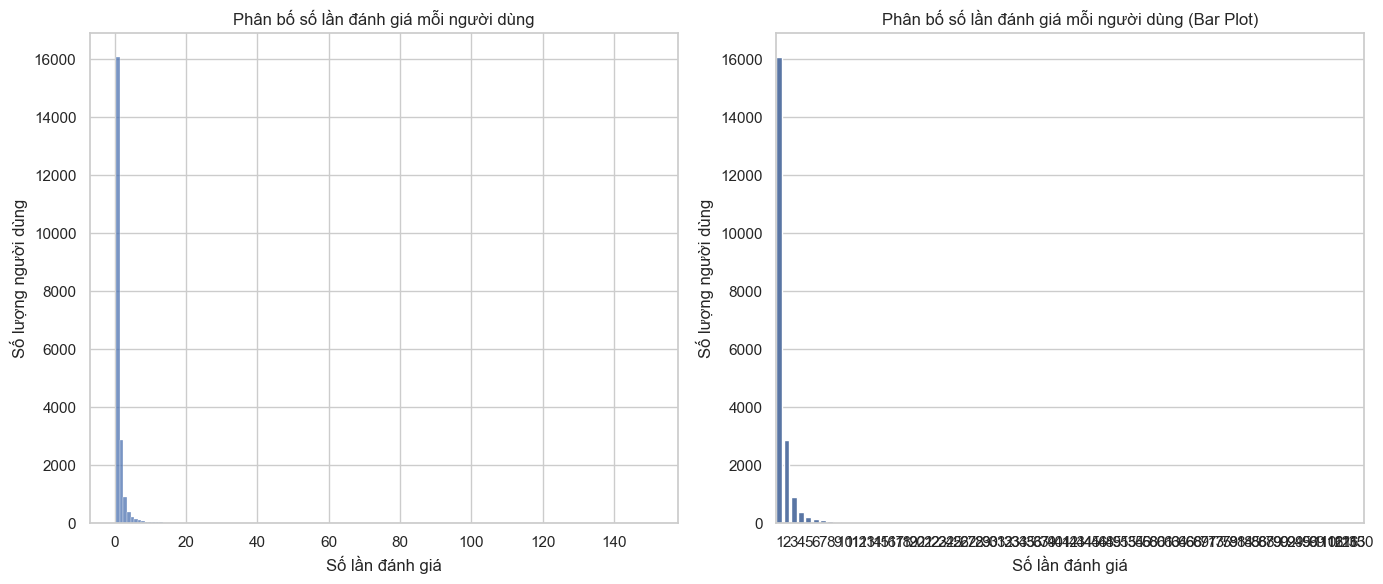

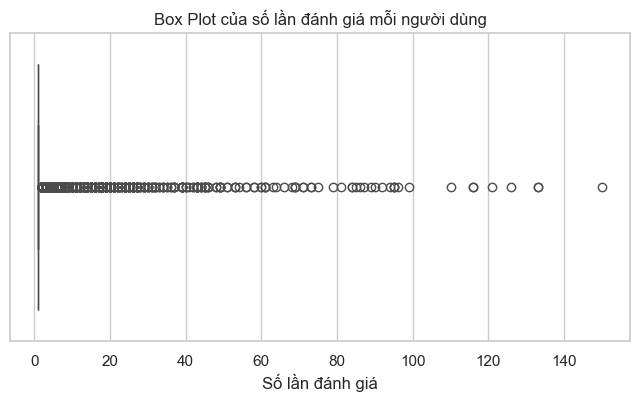

In [ ]:
import pandas as pd

# Đọc file all_reviews.csv
ratings_df = pd.read_csv('../data/all_reviews.csv')

# 1. Tổng số đánh giá
print("Tổng số đánh giá:", len(ratings_df))

# 2. Số lượng người dùng duy nhất
unique_users = ratings_df['username'].nunique()
print("Số lượng người dùng duy nhất:", unique_users)

# 3. Số lượng sản phẩm được đánh giá
unique_products = ratings_df['id_product'].nunique()
print("Số lượng sản phẩm được đánh giá:", unique_products)

# 4. Phân bố rating
print("\nPhân bố rating:")
rating_distribution = ratings_df['rating'].value_counts().sort_index()
print(rating_distribution)

# 5. Thống kê số đánh giá mỗi người dùng
ratings_per_user = ratings_df.groupby('username').size()
print("\nThống kê số đánh giá mỗi người dùng:")
print(ratings_per_user.describe())
print("\nPhân bố số đánh giá mỗi người dùng:")
ratings_per_user_distribution = ratings_per_user.value_counts().sort_index()
print(ratings_per_user_distribution)

# 6. Phân bố số đánh giá cao (rating >= rating_threshold)
rating_threshold = 4  # Có thể thay đổi thành 3 hoặc 2
high_ratings = ratings_df[ratings_df['rating'] >= rating_threshold]
ratings_per_user_high = high_ratings.groupby('username').size()
print(f"\nThống kê số đánh giá cao (rating >= {rating_threshold}) mỗi người dùng:")
print(ratings_per_user_high.describe())
print(f"\nPhân bố số đánh giá cao (rating >= {rating_threshold}) mỗi người dùng:")
print(ratings_per_user_high.value_counts().sort_index())

# 7. Kiểm tra dữ liệu trùng lặp
duplicates = ratings_df.duplicated().sum()
print("\nSố hàng trùng lặp:", duplicates)